In [81]:
import pandas as pd
df1 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df.csv")
pd.DataFrame(df1)

,Reviews for Samsung Galaxy Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,It's much better than watch ultra 2. Value for...,25-34,M,"Tirunelveli, Tamil Nadu",Working Professional,October,2021,Q4
1,Value for money ? No.\nQuality: built quality ...,35-44,M,"Bengaluru, Karnataka",Working Professional,April,2020,Q2
2,Just one word.......awesome. go for it,18-24,M,"Navi Mumbai, Maharashtra",Student,April,2020,Q2
3,"Android Users other than that of Samsung, you ...",55 and above,M,"New Delhi, Delhi",Retired,September,2020,Q3
4,Exalent watch,55 and above,F,"Devanahalli, Karnataka",Retired,May,2020,Q2
...,...,...,...,...,...,...,...,...
411,Best smartwatch in this time. Many more option...,25-34,F,"Patna, Bihar",Homemaker,March,2024,Q1
412,Not bad,18-24,F,"Kozhikode, Kerala",Working Professional,November,2020,Q4
413,Nice product with lot of features but battery ...,55 and above,F,"Navi Mumbai, Maharashtra",Homemaker,May,2021,Q2
414,Samsung Galaxy Watch 4 Classic LTE: A Comprehe...,25-34,M,"Lucknow, Uttar Pradesh",Freelancer,October,2023,Q4


In [83]:
from textblob import TextBlob

df1.columns

Index(['                    Reviews for Samsung Galaxy Watch ', 'Age',
       'Gender', 'Location', '        Occupation', 'Month', 'Year', 'Quarter'],
      dtype='object')

In [85]:
df1.columns = df1.columns.str.strip()
review_column = "Reviews for Samsung Galaxy Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df1[['Polarity', 'Sentiment']] = df1[review_column].apply(analyze_sentiment)
print(df1.head())

                    Reviews for Samsung Galaxy Watch           Age Gender  \
0  It's much better than watch ultra 2. Value for...         25-34      M   
1  Value for money ? No.\nQuality: built quality ...         35-44      M   
2             Just one word.......awesome. go for it         18-24      M   
3  Android Users other than that of Samsung, you ...  55 and above      M   
4                                      Exalent watch  55 and above      F   

                    Location            Occupation      Month  Year Quarter  \
0    Tirunelveli, Tamil Nadu  Working Professional    October  2021      Q4   
1       Bengaluru, Karnataka  Working Professional      April  2020      Q2   
2   Navi Mumbai, Maharashtra               Student      April  2020      Q2   
3           New Delhi, Delhi               Retired  September  2020      Q3   
4     Devanahalli, Karnataka               Retired        May  2020      Q2   

   Polarity Sentiment  
0  0.500000  Positive  
1  0.036296  P

In [87]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df1['state'] = df1['Location'].astype(str).apply(extract_state)
df1

,Reviews for Samsung Galaxy Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,It's much better than watch ultra 2. Value for...,25-34,M,"Tirunelveli, Tamil Nadu",Working Professional,October,2021,Q4,0.500000,Positive,Tamil Nadu
1,Value for money ? No.\nQuality: built quality ...,35-44,M,"Bengaluru, Karnataka",Working Professional,April,2020,Q2,0.036296,Positive,Karnataka
2,Just one word.......awesome. go for it,18-24,M,"Navi Mumbai, Maharashtra",Student,April,2020,Q2,0.000000,Neutral,Maharashtra
3,"Android Users other than that of Samsung, you ...",55 and above,M,"New Delhi, Delhi",Retired,September,2020,Q3,0.080556,Positive,Delhi
4,Exalent watch,55 and above,F,"Devanahalli, Karnataka",Retired,May,2020,Q2,0.000000,Neutral,Karnataka
...,...,...,...,...,...,...,...,...,...,...,...
411,Best smartwatch in this time. Many more option...,25-34,F,"Patna, Bihar",Homemaker,March,2024,Q1,0.633333,Positive,Bihar
412,Not bad,18-24,F,"Kozhikode, Kerala",Working Professional,November,2020,Q4,0.350000,Positive,Kerala
413,Nice product with lot of features but battery ...,55 and above,F,"Navi Mumbai, Maharashtra",Homemaker,May,2021,Q2,0.216667,Positive,Maharashtra
414,Samsung Galaxy Watch 4 Classic LTE: A Comprehe...,25-34,M,"Lucknow, Uttar Pradesh",Freelancer,October,2023,Q4,0.179167,Positive,Uttar Pradesh


In [89]:
df1 = df1[df1['state'] != 'Maharashtraj']
df1['state'].unique()
df1['Gender'].unique()
df1 = df1[df1['Gender'] != 'M ']

Total Reviews: 414
Reviews by Age Group:
Age
25-34           79
55 and above    72
45-54           68
35-44           67
Under 18        66
18-24           62
Name: count, dtype: int64
Reviews by Gender:
Gender
M     335
F      80
M       1
Name: count, dtype: int64
Reviews by State:
state
Karnataka            50
Maharashtra          49
Uttar Pradesh        36
Tamil Nadu           33
Kerala               29
West Bengal          27
Telangana            26
Andhra Pradesh       23
Delhi                20
Rajasthan            16
Haryana              14
Bihar                13
Odisha               12
Gujarat              11
Madhya Pradesh       10
Punjab                9
Chhattisgarh          7
Assam                 6
Jharkhand             6
Jammu and Kashmir     4
Himachal Pradesh      3
Manipur               2
Tripura               2
Uttarakhand           2
Puducherry            1
Daman and Diu         1
Sikkim                1
Goa                   1
Name: count, dtype: int64
Reviews by 

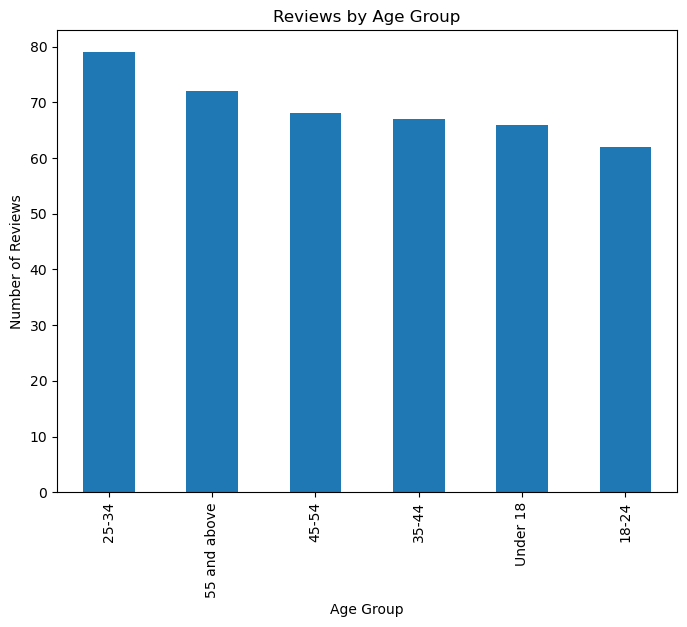

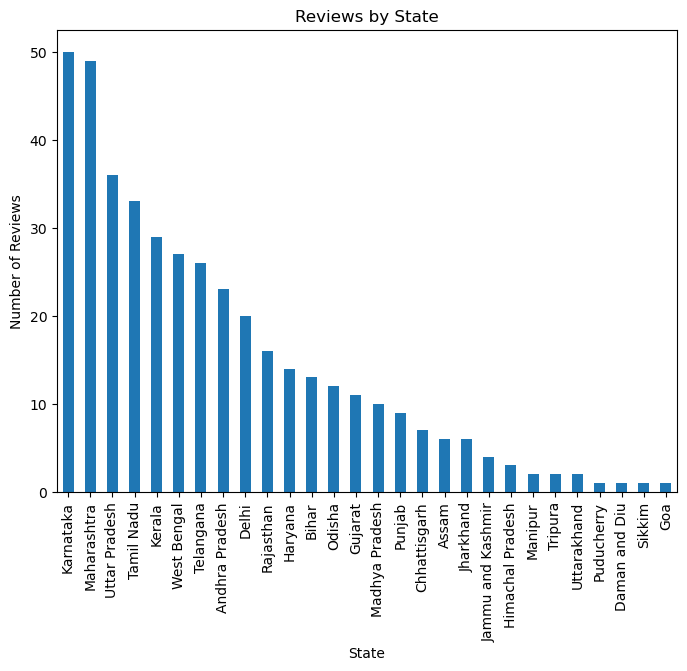

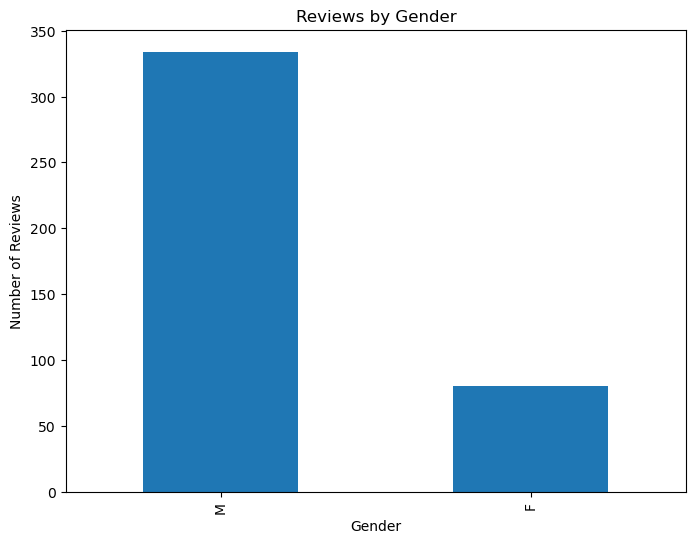

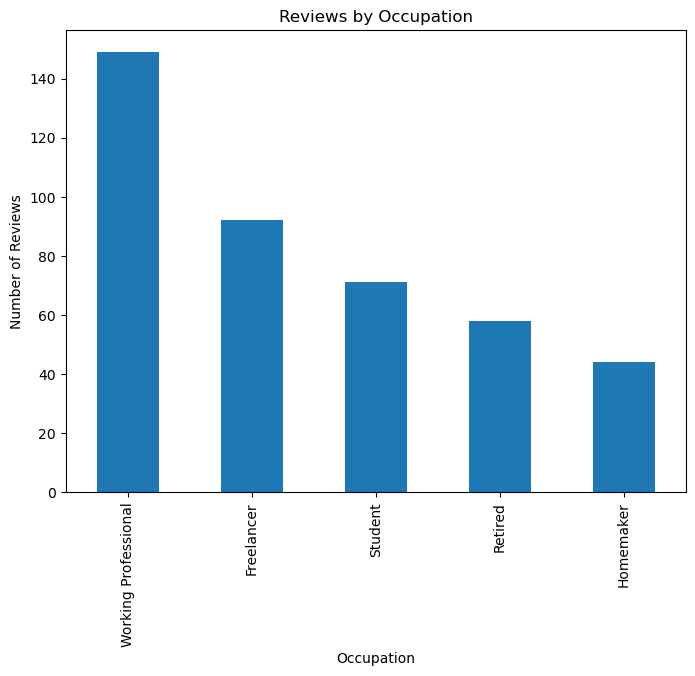

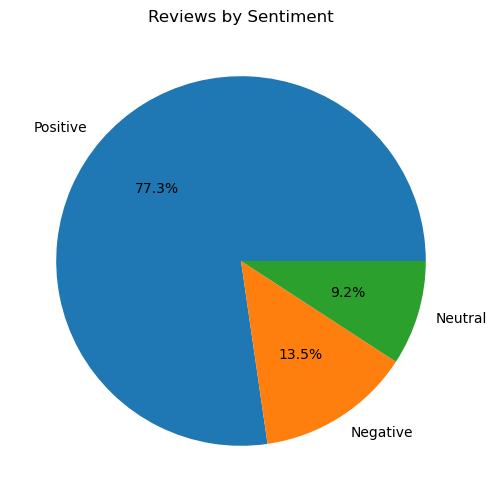

In [63]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df1)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df1[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)

reviews_by_gender = df1[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender_group)

# 3. Reviews by Location
reviews_by_state = df1[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df1[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df1[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(Samsung)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_State(Samsung)[Usage Analysis].png")
plt.show()

plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Samsung)[Usage Analysis].png")
plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(Samsung)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("overall_sentiment(Samsung)[Usage Analysis].png")
plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [95]:
df2 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df2.csv")
pd.DataFrame(df2)

,Reviews for Apple Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,The product is a beast ! Feels premium and is ...,25-34,F,"Kalyan, Maharashtra",Homemaker,June,2021,Q2
1,Apple watch Ultra 2 is a beast when it comes t...,55 and above,M,"Kanpur, Uttar Pradesh",Retired,July,2024,Q3
2,Very good product nice Apple Watch thanks flip...,25-34,M,"Chennai, Tamil Nadu",Working Professional,June,2021,Q2
3,Very nice product,35-44,M,"Ahmadnagar, Maharashtra",Working Professional,May,2023,Q2
4,"Nothing to say more , its just a beast in its ...",45-54,F,"West Godavari, Andhra Pradesh",Homemaker,January,2023,Q1
...,...,...,...,...,...,...,...,...
326,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,October,2024,Q4
327,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,November,2020,Q4
328,Awesome Watch,55 and above,F,"Ahmedabad, Gujarat",Retired,November,2023,Q4
329,Looks premium and special,25-34,M,"Bengaluru, Karnataka",Working Professional,August,2021,Q3


In [97]:
df2.columns = df2.columns.str.strip()
review_column = "Reviews for Apple Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df2[['Polarity', 'Sentiment']] = df2[review_column].apply(analyze_sentiment)
print(df2.head())

                             Reviews for Apple Watch           Age Gender  \
0  The product is a beast ! Feels premium and is ...         25-34      F   
1  Apple watch Ultra 2 is a beast when it comes t...  55 and above      M   
2  Very good product nice Apple Watch thanks flip...         25-34      M   
3                                  Very nice product         35-44      M   
4  Nothing to say more , its just a beast in its ...         45-54      F   

                         Location            Occupation    Month  Year  \
0             Kalyan, Maharashtra             Homemaker     June  2021   
1           Kanpur, Uttar Pradesh               Retired     July  2024   
2             Chennai, Tamil Nadu  Working Professional     June  2021   
3         Ahmadnagar, Maharashtra  Working Professional      May  2023   
4   West Godavari, Andhra Pradesh             Homemaker  January  2023   

  Quarter  Polarity Sentiment  
0      Q2  0.000000   Neutral  
1      Q3  0.250000  Positiv

In [98]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df2['state'] = df2['Location'].astype(str).apply(extract_state)
df2

,Reviews for Apple Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,The product is a beast ! Feels premium and is ...,25-34,F,"Kalyan, Maharashtra",Homemaker,June,2021,Q2,0.000000,Neutral,Maharashtra
1,Apple watch Ultra 2 is a beast when it comes t...,55 and above,M,"Kanpur, Uttar Pradesh",Retired,July,2024,Q3,0.250000,Positive,Uttar Pradesh
2,Very good product nice Apple Watch thanks flip...,25-34,M,"Chennai, Tamil Nadu",Working Professional,June,2021,Q2,0.570000,Positive,Tamil Nadu
3,Very nice product,35-44,M,"Ahmadnagar, Maharashtra",Working Professional,May,2023,Q2,0.780000,Positive,Maharashtra
4,"Nothing to say more , its just a beast in its ...",45-54,F,"West Godavari, Andhra Pradesh",Homemaker,January,2023,Q1,0.376429,Positive,Andhra Pradesh
...,...,...,...,...,...,...,...,...,...,...,...
326,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,October,2024,Q4,0.420357,Positive,Uttar Pradesh
327,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,November,2020,Q4,0.420357,Positive,Uttar Pradesh
328,Awesome Watch,55 and above,F,"Ahmedabad, Gujarat",Retired,November,2023,Q4,1.000000,Positive,Gujarat
329,Looks premium and special,25-34,M,"Bengaluru, Karnataka",Working Professional,August,2021,Q3,0.357143,Positive,Karnataka


In [101]:
df2['state'].unique()

array(['Maharashtra', 'Uttar Pradesh', 'Tamil Nadu', 'Andhra Pradesh',
       'Delhi', 'Karnataka', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Assam', 'Jammu and Kashmir', 'Rajasthan', 'Telangana', 'Kerala',
       'Jharkhand', 'Haryana', 'Punjab', 'Gujarat', 'Chhattisgarh',
       'Bihar', 'Meghalaya', 'Madhya Pradesh', 'Goa'], dtype=object)

Total Reviews: 331
Reviews by Age Group:
Age
55 and above    69
18-24           68
35-44           57
25-34           54
Under 18        44
45-54           39
Name: count, dtype: int64
Reviews by State:
state
Maharashtra          43
Uttar Pradesh        38
Karnataka            36
West Bengal          25
Telangana            25
Tamil Nadu           22
Andhra Pradesh       22
Gujarat              16
Haryana              14
Kerala               13
Delhi                13
Madhya Pradesh        9
Bihar                 9
Rajasthan             8
Jharkhand             7
Punjab                7
Odisha                7
Jammu and Kashmir     4
Assam                 4
Chhattisgarh          3
Uttarakhand           3
Goa                   2
Meghalaya             1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    105
Freelancer               68
Retired                  61
Homemaker                49
Student                  48
Name: count, dtype: int64
Reviews by Ge

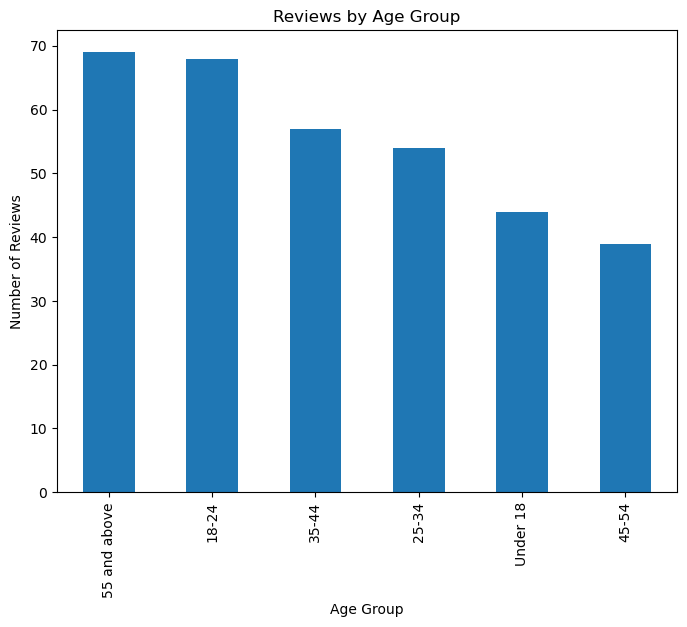

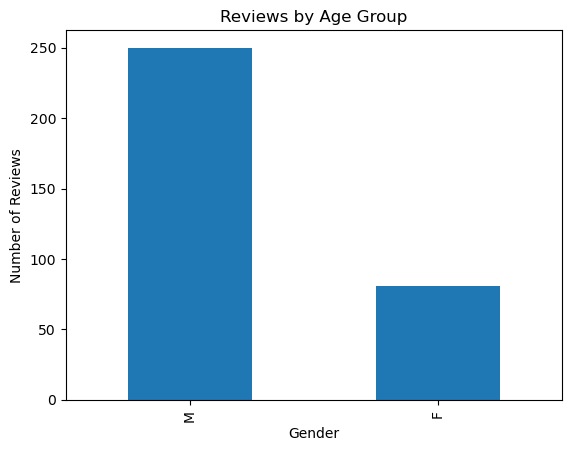

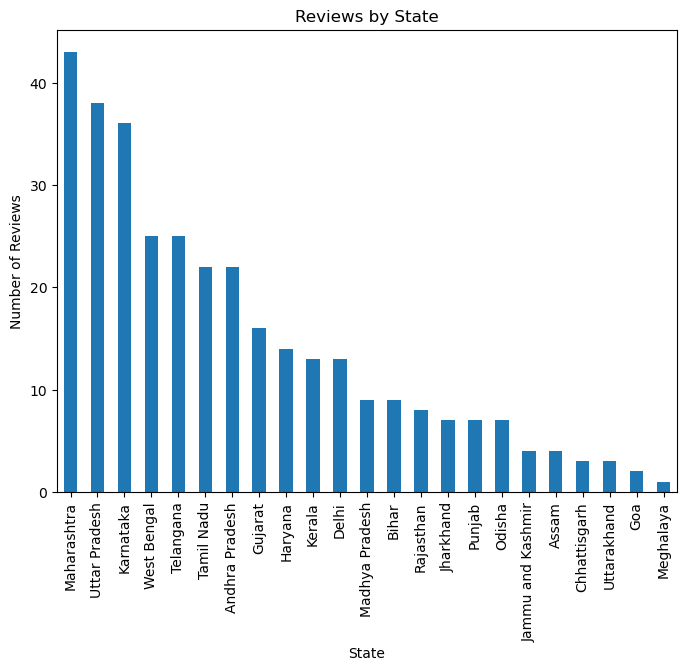

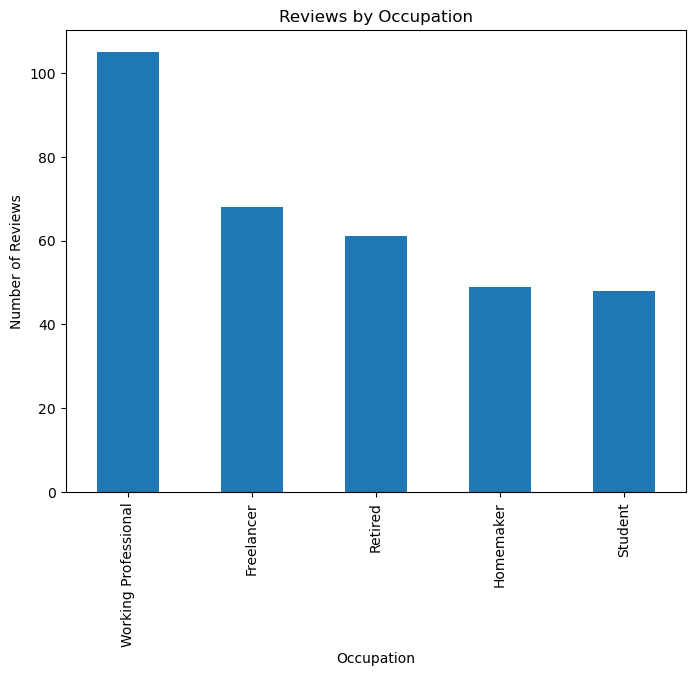

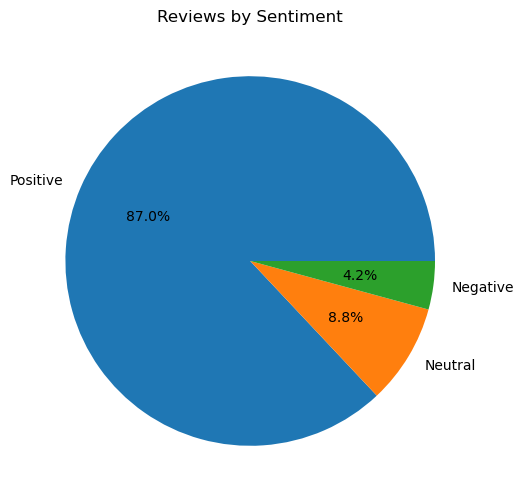

In [77]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = 'Gender'
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df2)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df2[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)

# 3. Reviews by Location
reviews_by_state = df2[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df2[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)
reviews_by_gender = df2[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender)

# 5. Reviews by Sentiment
reviews_by_sentiment = df2[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(Apple)[Usage Analysis].png")
plt.show()
reviews_by_gender.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Apple)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_State(Apple)[Usage Analysis].png")
plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(Apple)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(Apple)[Usage Analysis].png")
plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [105]:
df3 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df3.csv")
pd.DataFrame(df3)

,Reviews for Noise,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I'm in love with thi product thnks filpkart fo...,25-34,F,"Agra, Uttar Pradesh",Homemaker,September,2023,Q3
1,Loved 😍,45-54,F,"Kolkata, West Bengal",Homemaker,September,2021,Q3
2,VERY NICE 👍 WATCH I'M IMPRESSED 😊 GOOD SERVICE...,55 and above,M,"Mokameh, Bihar",Retired,June,2022,Q2
3,Superb Watch Under This price Range.......\nVa...,45-54,M,"Sultanpur, Uttar Pradesh",Working Professional,July,2024,Q3
4,Nice 👍,Under 18,M,"Kolkata, West Bengal",Student,October,2022,Q4
...,...,...,...,...,...,...,...,...
547,Waste of money,Under 18,F,"Northern Division, Odisha",Student,August,2024,Q3
548,Great experience!!,25-34,F,"Chennai, Tamil Nadu",Homemaker,April,2021,Q2
549,Product was good,25-34,M,"Pune, Maharashtra",Freelancer,February,2024,Q1
550,Good,55 and above,M,"Bengaluru, Karnataka",Freelancer,February,2024,Q1


In [107]:
df3.columns = df3.columns.str.strip()
review_column = "Reviews for Noise"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df3[['Polarity', 'Sentiment']] = df3[review_column].apply(analyze_sentiment)
print(df3.head())

                                   Reviews for Noise           Age Gender  \
0  I'm in love with thi product thnks filpkart fo...         25-34      F   
1                                            Loved 😍         45-54      F   
2  VERY NICE 👍 WATCH I'M IMPRESSED 😊 GOOD SERVICE...  55 and above      M   
3  Superb Watch Under This price Range.......\nVa...         45-54      M   
4                                             Nice 👍      Under 18      M   

                    Location            Occupation      Month  Year Quarter  \
0        Agra, Uttar Pradesh             Homemaker  September  2023      Q3   
1       Kolkata, West Bengal             Homemaker  September  2021      Q3   
2             Mokameh, Bihar               Retired       June  2022      Q2   
3   Sultanpur, Uttar Pradesh  Working Professional       July  2024      Q3   
4       Kolkata, West Bengal               Student    October  2022      Q4   

   Polarity Sentiment  
0  0.400000  Positive  
1  0.700000  P

In [108]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df3['state'] = df3['Location'].astype(str).apply(extract_state)
df3

,Reviews for Noise,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I'm in love with thi product thnks filpkart fo...,25-34,F,"Agra, Uttar Pradesh",Homemaker,September,2023,Q3,0.400000,Positive,Uttar Pradesh
1,Loved 😍,45-54,F,"Kolkata, West Bengal",Homemaker,September,2021,Q3,0.700000,Positive,West Bengal
2,VERY NICE 👍 WATCH I'M IMPRESSED 😊 GOOD SERVICE...,55 and above,M,"Mokameh, Bihar",Retired,June,2022,Q2,0.826667,Positive,Bihar
3,Superb Watch Under This price Range.......\nVa...,45-54,M,"Sultanpur, Uttar Pradesh",Working Professional,July,2024,Q3,0.766667,Positive,Uttar Pradesh
4,Nice 👍,Under 18,M,"Kolkata, West Bengal",Student,October,2022,Q4,0.600000,Positive,West Bengal
...,...,...,...,...,...,...,...,...,...,...,...
547,Waste of money,Under 18,F,"Northern Division, Odisha",Student,August,2024,Q3,-0.200000,Negative,Odisha
548,Great experience!!,25-34,F,"Chennai, Tamil Nadu",Homemaker,April,2021,Q2,1.000000,Positive,Tamil Nadu
549,Product was good,25-34,M,"Pune, Maharashtra",Freelancer,February,2024,Q1,0.700000,Positive,Maharashtra
550,Good,55 and above,M,"Bengaluru, Karnataka",Freelancer,February,2024,Q1,0.700000,Positive,Karnataka


In [41]:
df3 = df3[df3['state'] != 'West bengal']
df3['state'].unique()

array(['Uttar Pradesh', 'West Bengal', 'Bihar', 'Delhi', 'Maharashtra',
       'Assam', 'Telangana', 'Karnataka', 'Odisha', 'Andhra Pradesh',
       'Kerala', 'Chhattisgarh', 'Haryana', 'Rajasthan', 'Punjab',
       'Uttarakhand', 'Jharkhand', 'Gujarat', 'Madhya Pradesh',
       'Tamil Nadu', 'Tripura', 'Goa', 'Manipur', 'Nagaland',
       'Jammu and Kashmir'], dtype=object)

In [43]:
df3 = df3[df3['Age'] != 'Under 18, 18-24']
df3['Age'].unique()

array(['25-34', '45-54', '55 and above', 'Under 18', '35-44', '18-24'],
      dtype=object)

Total Reviews: 551
Reviews by Age Group:
Age
18-24           109
Under 18        108
25-34            93
55 and above     84
35-44            80
45-54            77
Name: count, dtype: int64
Reviews by State:
state
West Bengal          86
Uttar Pradesh        80
Maharashtra          70
Bihar                47
Karnataka            35
Odisha               31
Andhra Pradesh       20
Tamil Nadu           19
Madhya Pradesh       19
Haryana              19
Telangana            18
Gujarat              18
Rajasthan            17
Assam                14
Delhi                13
Jharkhand            11
Kerala                8
Chhattisgarh          7
Punjab                5
Uttarakhand           5
Goa                   3
Tripura               2
Jammu and Kashmir     2
Manipur               1
Nagaland              1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    150
Student                 119
Freelancer              114
Homemaker               113
Retired      

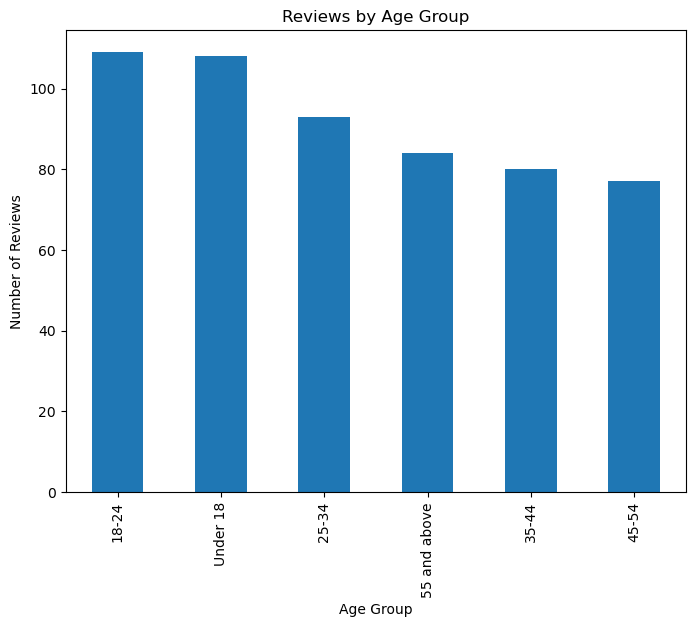

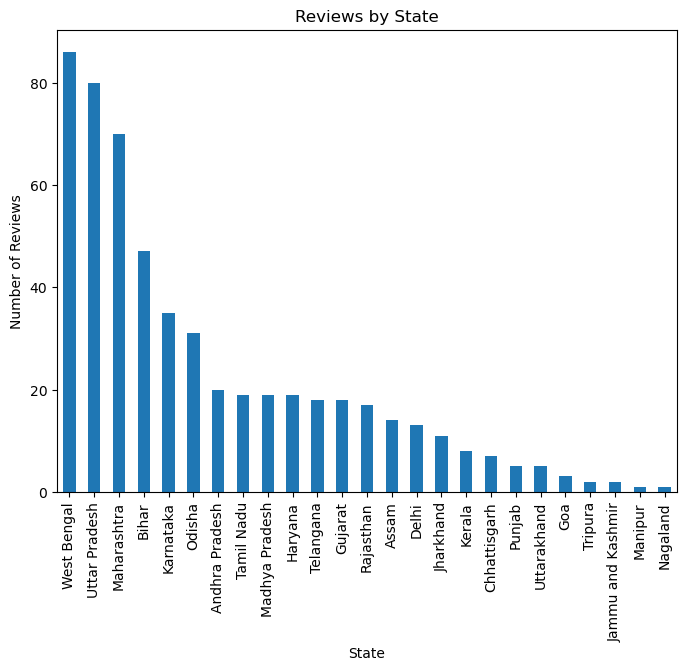

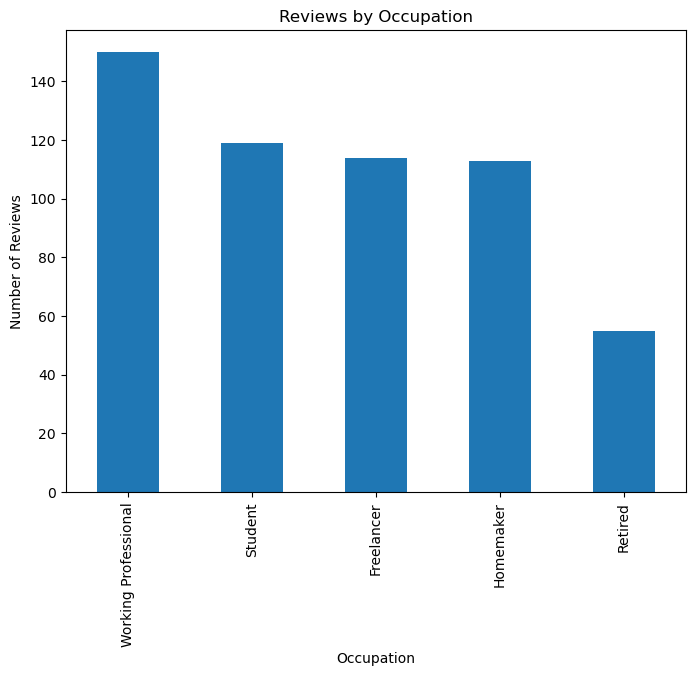

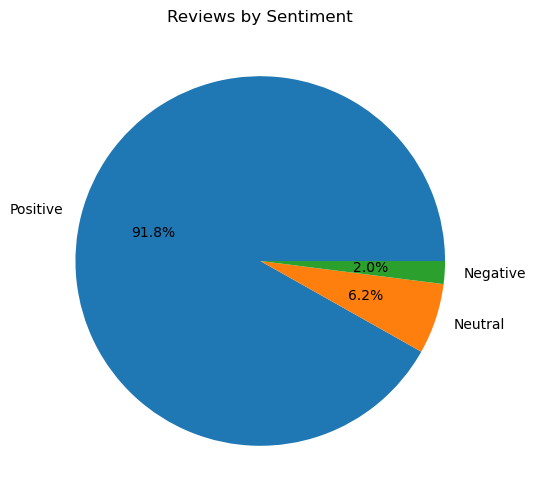

In [45]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df3)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df3[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)

# 3. Reviews by Location
reviews_by_state = df3[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df3[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df3[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(Noise)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Noise)[Usage Analysis].png")
plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(Noise)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(Noise)[Usage Analysis].png")
plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [49]:
df4 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df4.csv")
pd.DataFrame(df4)

,Reviews for OnePlus Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Good but with flaws\nI have been a samsung wat...,25-34,M,"Chennai, Tamil Nadu",Working Professional,April,2021,Q2
1,Loved it.,18-24,F,"Bengaluru, Karnataka",Working Professional,February,2022,Q1
2,My first smart watch\nWatch was awesome and su...,45-54,M,"Gonikoppal, Karnataka",Working Professional,September,2022,Q3
3,Perfect😍\nBest in Class,35-44,M,"Nellikuppam, Tamil Nadu",Working Professional,December,2024,Q4
4,"In one word...\n\nwe can say,\n\nunbelievable..!!",55 and above,M,"New Delhi, Delhi",Retired,September,2021,Q3
...,...,...,...,...,...,...,...,...
64,Don't,Under 18,M,"Mumbai, Maharashtra",Student,October,2024,Q4
65,I don’t personally use wearable health devices...,18-24,M,"Mumbai, Maharashtra",Student,August,2022,Q3
66,Helpful for tracking steps and quality of sleep,18-24,M,"Mumbai, Maharashtra",Student,September,2020,Q3
67,Well \n\n\n\n,35-44,M,"Aurangabad, Maharashtra",Working Professional,April,2023,Q2


In [51]:
df4.columns = df4.columns.str.strip()
review_column = "Reviews for OnePlus Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df4[['Polarity', 'Sentiment']] = df4[review_column].apply(analyze_sentiment)
print(df4.head())

                           Reviews for OnePlus Watch           Age Gender  \
0  Good but with flaws\nI have been a samsung wat...         25-34      M   
1                                          Loved it.         18-24      F   
2  My first smart watch\nWatch was awesome and su...         45-54      M   
3                            Perfect😍\nBest in Class         35-44      M   
4  In one word...\n\nwe can say,\n\nunbelievable..!!  55 and above      M   

                   Location            Occupation      Month  Year Quarter  \
0       Chennai, Tamil Nadu  Working Professional      April  2021      Q2   
1      Bengaluru, Karnataka  Working Professional   February  2022      Q1   
2     Gonikoppal, Karnataka  Working Professional  September  2022      Q3   
3   Nellikuppam, Tamil Nadu  Working Professional   December  2024      Q4   
4          New Delhi, Delhi               Retired  September  2021      Q3   

   Polarity Sentiment  
0  0.403030  Positive  
1  0.700000  Positiv

In [53]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df4['state'] = df4['Location'].astype(str).apply(extract_state)
df4

,Reviews for OnePlus Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Good but with flaws\nI have been a samsung wat...,25-34,M,"Chennai, Tamil Nadu",Working Professional,April,2021,Q2,0.403030,Positive,Tamil Nadu
1,Loved it.,18-24,F,"Bengaluru, Karnataka",Working Professional,February,2022,Q1,0.700000,Positive,Karnataka
2,My first smart watch\nWatch was awesome and su...,45-54,M,"Gonikoppal, Karnataka",Working Professional,September,2022,Q3,0.399524,Positive,Karnataka
3,Perfect😍\nBest in Class,35-44,M,"Nellikuppam, Tamil Nadu",Working Professional,December,2024,Q4,1.000000,Positive,Tamil Nadu
4,"In one word...\n\nwe can say,\n\nunbelievable..!!",55 and above,M,"New Delhi, Delhi",Retired,September,2021,Q3,-0.390625,Negative,Delhi
...,...,...,...,...,...,...,...,...,...,...,...
64,Don't,Under 18,M,"Mumbai, Maharashtra",Student,October,2024,Q4,0.000000,Neutral,Maharashtra
65,I don’t personally use wearable health devices...,18-24,M,"Mumbai, Maharashtra",Student,August,2022,Q3,0.025000,Positive,Maharashtra
66,Helpful for tracking steps and quality of sleep,18-24,M,"Mumbai, Maharashtra",Student,September,2020,Q3,0.000000,Neutral,Maharashtra
67,Well \n\n\n\n,35-44,M,"Aurangabad, Maharashtra",Working Professional,April,2023,Q2,0.000000,Neutral,Maharashtra


In [55]:
df4['state'].unique()

array(['Tamil Nadu', 'Karnataka', 'Delhi', 'Maharashtra',
       'Andhra Pradesh', 'West Bengal', 'Haryana', 'Bihar',
       'Madhya Pradesh', 'Uttarakhand', 'Kerala', 'Jharkhand',
       'Telangana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Odisha',
       'Gujarat', 'Uttar Pradesh'], dtype=object)

Total Reviews: 69
Reviews by Age Group:
Age
25-34           15
45-54           14
18-24           13
55 and above    13
35-44            7
Under 18         7
Name: count, dtype: int64
Reviews by State:
state
West Bengal          11
Karnataka            11
Maharashtra           9
Tamil Nadu            7
Andhra Pradesh        7
Delhi                 4
Haryana               4
Bihar                 3
Kerala                3
Telangana             2
Jammu and Kashmir     1
Gujarat               1
Odisha                1
Uttarakhand           1
Himachal Pradesh      1
Jharkhand             1
Madhya Pradesh        1
Uttar Pradesh         1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    30
Freelancer              17
Retired                 11
Student                  9
Homemaker                2
Name: count, dtype: int64
Reviews by Sentiment:
Sentiment
Positive    51
Neutral     10
Negative     8
Name: count, dtype: int64


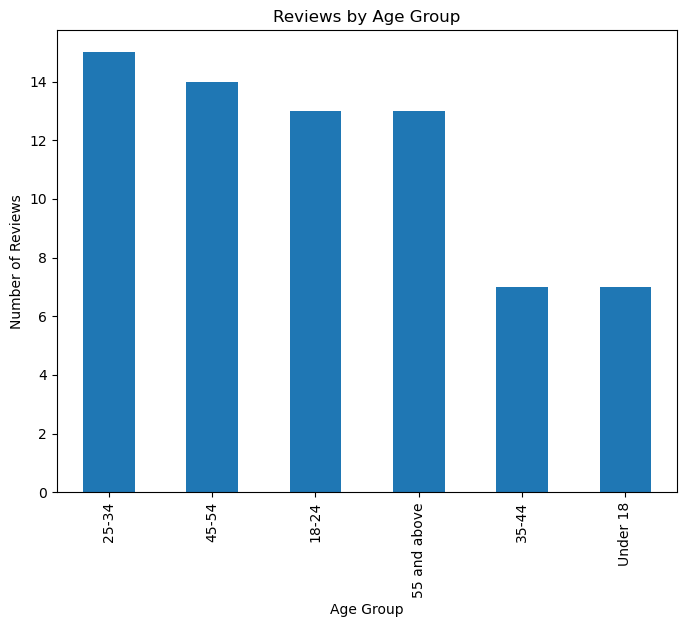

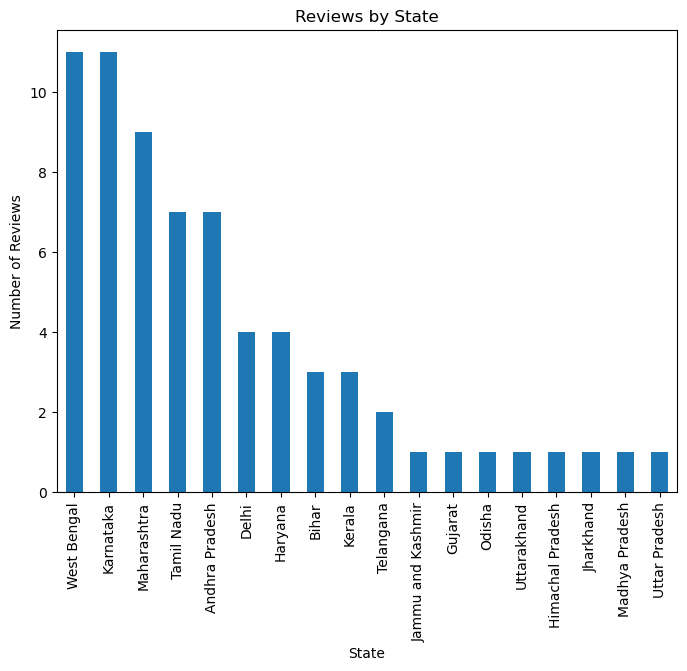

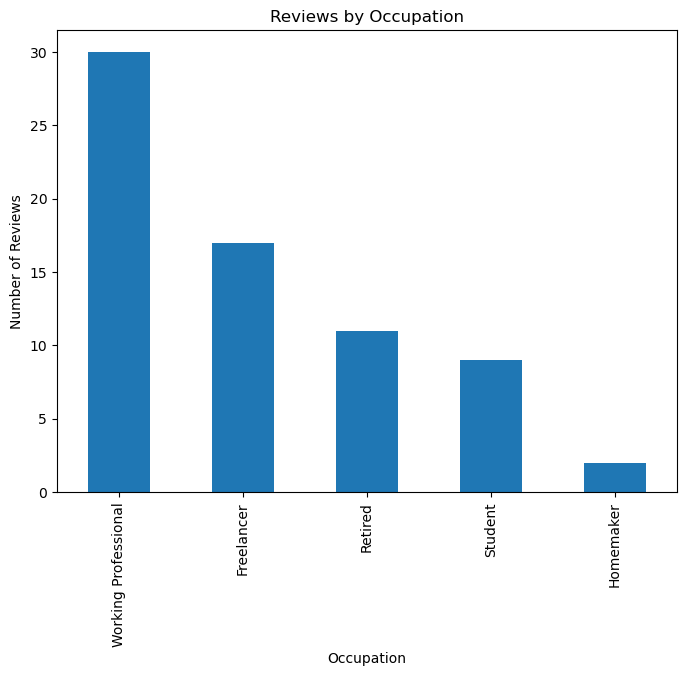

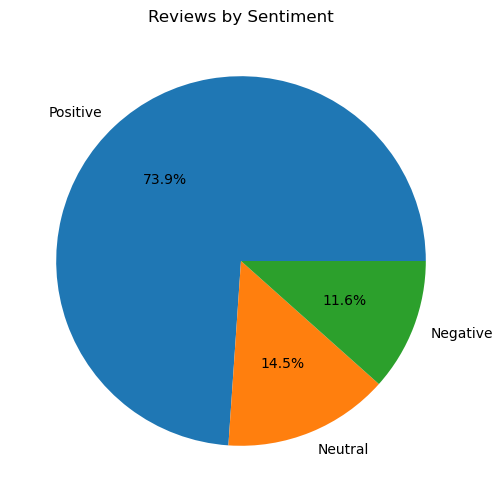

In [57]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df4)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df4[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)

# 3. Reviews by Location
reviews_by_state = df4[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df4[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df4[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(OnePlus)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(OnePlus)[Usage Analysis].png")
plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(OnePlus)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(OnePlus)[Usage Analysis].png")
plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [113]:
df5 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df5.csv")
pd.DataFrame(df5)

,Reviews for Redmi Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Watch is big in size but looks professional. B...,35-44,F,"Bhubaneswar, Odisha",Homemaker,December,2022,Q4
1,Best smartwatch in this budget with calling an...,45-54,M,"Ghaziabad, Uttar Pradesh",Freelancer,May,2022,Q2
2,The size is too big and it can be slim too. If...,35-44,M,"Madurai, Tamil Nadu",Freelancer,January,2020,Q1
3,Everything is perfect.\nBest of budget smartwa...,18-24,F,"Burdwan, West Bengal",Working Professional,April,2022,Q2
4,Battery back up is superb\nConnectivity is als...,35-44,M,"Gandhinagar, Gujarat",Working Professional,September,2020,Q3
...,...,...,...,...,...,...,...,...
276,Such a wonderful watch!,18-24,F,"Prayagraj, Uttar Pradesh",Working Professional,October,2021,Q4
277,Nc,18-24,M,"Kendrapara, Odisha",Working Professional,July,2020,Q3
278,It is a nice working design with a good lookin...,45-54,F,"Srinagar, Jammu and Kashmir",Homemaker,March,2024,Q1
279,"I use to measure heart beats, distance I walked.",35-44,F,"Mumbai, Maharashtra",Working Professional,February,2020,Q1


In [115]:
df5.columns = df5.columns.str.strip()
review_column = "Reviews for Redmi Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df5[['Polarity', 'Sentiment']] = df5[review_column].apply(analyze_sentiment)
print(df5.head())

                             Reviews for Redmi Watch    Age Gender  \
0  Watch is big in size but looks professional. B...  35-44      F   
1  Best smartwatch in this budget with calling an...  45-54      M   
2  The size is too big and it can be slim too. If...  35-44      M   
3  Everything is perfect.\nBest of budget smartwa...  18-24      F   
4  Battery back up is superb\nConnectivity is als...  35-44      M   

                    Location            Occupation      Month  Year Quarter  \
0        Bhubaneswar, Odisha             Homemaker   December  2022      Q4   
1   Ghaziabad, Uttar Pradesh            Freelancer        May  2022      Q2   
2        Madurai, Tamil Nadu            Freelancer    January  2020      Q1   
3       Burdwan, West Bengal  Working Professional      April  2022      Q2   
4      Gandhinagar, Gujarat   Working Professional  September  2020      Q3   

   Polarity Sentiment  
0  0.260000  Positive  
1  0.315741  Positive  
2 -0.041667  Negative  
3  1.000

In [117]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df5['state'] = df5['Location'].astype(str).apply(extract_state)
df5

,Reviews for Redmi Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Watch is big in size but looks professional. B...,35-44,F,"Bhubaneswar, Odisha",Homemaker,December,2022,Q4,0.260000,Positive,Odisha
1,Best smartwatch in this budget with calling an...,45-54,M,"Ghaziabad, Uttar Pradesh",Freelancer,May,2022,Q2,0.315741,Positive,Uttar Pradesh
2,The size is too big and it can be slim too. If...,35-44,M,"Madurai, Tamil Nadu",Freelancer,January,2020,Q1,-0.041667,Negative,Tamil Nadu
3,Everything is perfect.\nBest of budget smartwa...,18-24,F,"Burdwan, West Bengal",Working Professional,April,2022,Q2,1.000000,Positive,West Bengal
4,Battery back up is superb\nConnectivity is als...,35-44,M,"Gandhinagar, Gujarat",Working Professional,September,2020,Q3,0.438492,Positive,Gujarat
...,...,...,...,...,...,...,...,...,...,...,...
276,Such a wonderful watch!,18-24,F,"Prayagraj, Uttar Pradesh",Working Professional,October,2021,Q4,0.500000,Positive,Uttar Pradesh
277,Nc,18-24,M,"Kendrapara, Odisha",Working Professional,July,2020,Q3,0.000000,Neutral,Odisha
278,It is a nice working design with a good lookin...,45-54,F,"Srinagar, Jammu and Kashmir",Homemaker,March,2024,Q1,0.477857,Positive,Jammu and Kashmir
279,"I use to measure heart beats, distance I walked.",35-44,F,"Mumbai, Maharashtra",Working Professional,February,2020,Q1,0.000000,Neutral,Maharashtra


In [119]:
df5 = df5[df5['state'] != 'Maharshtra']
df5['state'].unique()

array(['Odisha', 'Uttar Pradesh', 'Tamil Nadu', 'West Bengal', 'Gujarat',
       'Telangana', 'Jharkhand', 'Madhya Pradesh', 'Haryana',
       'Maharashtra', 'Kerala', 'Rajasthan', 'Karnataka', 'Delhi',
       'Bihar', 'Punjab', 'Himachal Pradesh', 'Jammu and Kashmir',
       'Andhra Pradesh', 'Mizoram', 'Goa', 'Manipur', 'Meghalaya',
       'Uttarakhand', 'Chhattisgarh', 'Assam'], dtype=object)

Total Reviews: 280
Reviews by Age Group:
Age
35-44           57
55 and above    50
45-54           49
Under 18        44
25-34           41
18-24           39
Name: count, dtype: int64
Reviews by Age Group:
Age
35-44           57
55 and above    50
45-54           49
Under 18        44
25-34           41
18-24           39
Name: count, dtype: int64
Reviews by State:
state
Uttar Pradesh        41
Karnataka            29
Tamil Nadu           24
West Bengal          22
Maharashtra          21
Telangana            19
Bihar                19
Andhra Pradesh       16
Delhi                12
Gujarat              12
Odisha               11
Punjab                9
Kerala                8
Rajasthan             6
Haryana               6
Madhya Pradesh        6
Chhattisgarh          4
Jharkhand             3
Himachal Pradesh      2
Jammu and Kashmir     2
Uttarakhand           2
Assam                 2
Mizoram               1
Goa                   1
Manipur               1
Meghalaya             1
N

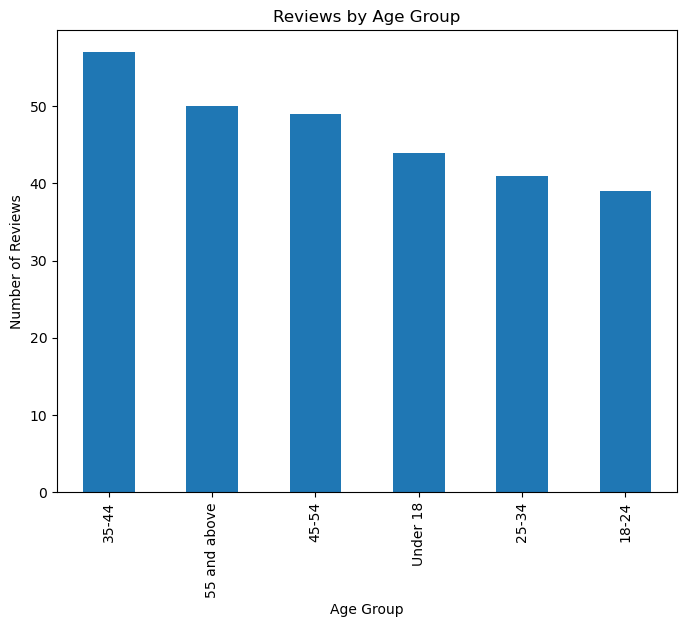

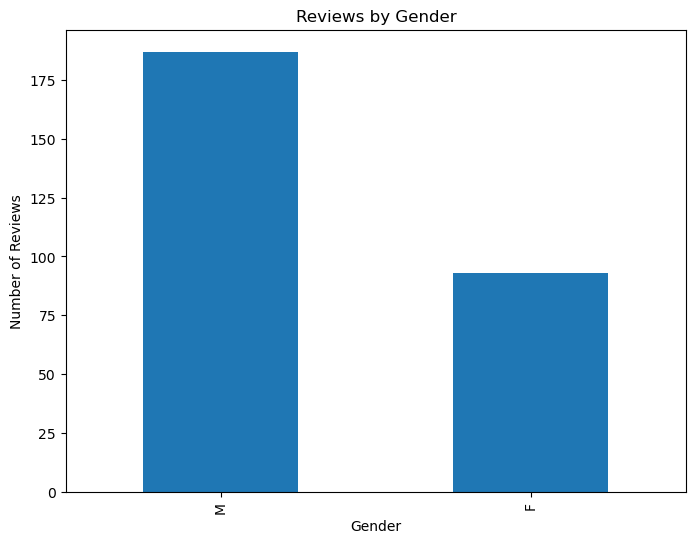

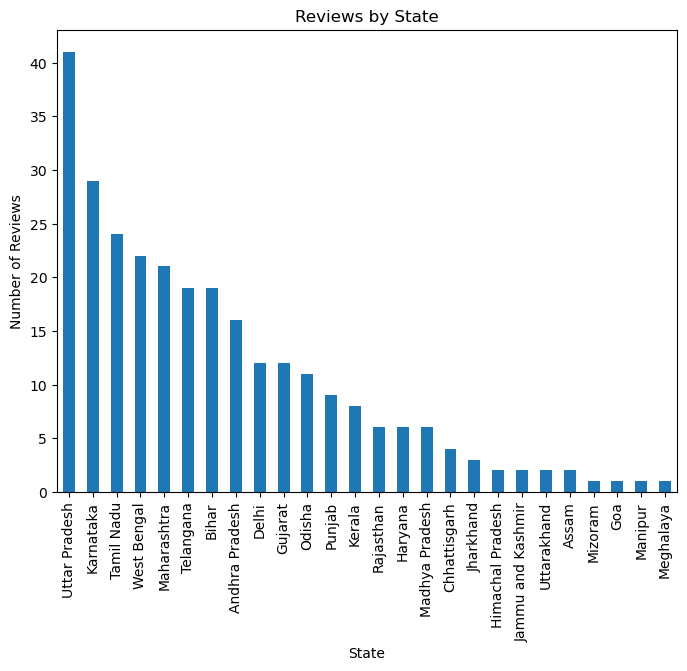

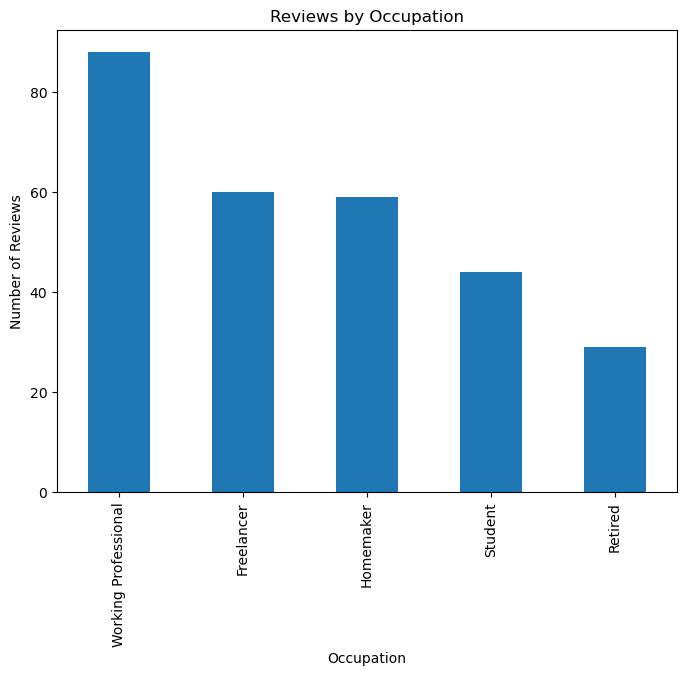

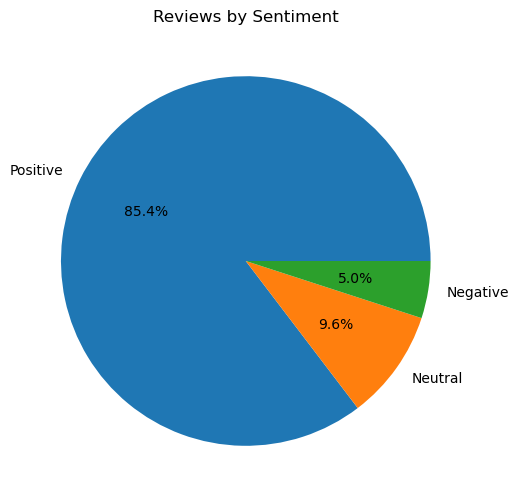

In [121]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df5)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df5[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df5[gender_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)

# 3. Reviews by Location
reviews_by_state = df5[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df5[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df5[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(Redmi)[Usage Analysis].png")
plt.show()
plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_Gender(Redmi)[Usage Analysis].png")
plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_State(Redmi)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(Redmi)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(Redmi)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [27]:
df6 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df6.csv")
pd.DataFrame(df6)

,Reviews for Mi SmartBand,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Good product at this price.,55 and above,M,"Hugli Chinsurah, West Bengal",Retired,June,2021,Q2
1,Best product and it is the original MI Smart B...,25-34,M,"Kottarakkara, Kerala",Working Professional,September,2022,Q3
2,Nice product,45-54,F,"Ranbirsinghpora, Jammu and Kashmir",Homemaker,April,2023,Q2
3,"Really great product I love very much, plzz go...",35-44,F,"Gopeshwar, Uttarakhand",Homemaker,February,2022,Q1
4,Best ...Smooth ...,45-54,M,"Lucknow, Uttar Pradesh",Working Professional,July,2020,Q3
...,...,...,...,...,...,...,...,...
347,awesome product. has a good and soft strap and...,35-44,M,"Eravattur, Kerala",Freelancer,December,2022,Q4
348,amazing something accurate pedometer\nheart ra...,45-54,M,"Chhatarpur, Madhya Pradesh",Working Professional,March,2022,Q1
349,this is the best and excellent work I am happy...,45-54,F,"Mumbai, Maharashtra",Homemaker,March,2022,Q1
350,I was thinking of getting a smart watch for a ...,Under 18,F,"Kolkata, West Bengal",Student,August,2024,Q3


In [28]:
df6.columns = df6.columns.str.strip()
review_column = "Reviews for Mi SmartBand"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df6[['Polarity', 'Sentiment']] = df6[review_column].apply(analyze_sentiment)
print(df6.head())

                            Reviews for Mi SmartBand           Age Gender  \
0                        Good product at this price.  55 and above      M   
1  Best product and it is the original MI Smart B...         25-34      M   
2                                       Nice product         45-54      F   
3  Really great product I love very much, plzz go...         35-44      F   
4                                 Best ...Smooth ...         45-54      M   

                              Location            Occupation      Month  Year  \
0         Hugli Chinsurah, West Bengal               Retired       June  2021   
1                 Kottarakkara, Kerala  Working Professional  September  2022   
2   Ranbirsinghpora, Jammu and Kashmir             Homemaker      April  2023   
3               Gopeshwar, Uttarakhand             Homemaker   February  2022   
4               Lucknow, Uttar Pradesh  Working Professional       July  2020   

  Quarter  Polarity Sentiment  
0      Q2   0.7000

In [31]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df6['state'] = df6['Location'].astype(str).apply(extract_state)
df6

,Reviews for Mi SmartBand,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Good product at this price.,55 and above,M,"Hugli Chinsurah, West Bengal",Retired,June,2021,Q2,0.700000,Positive,West Bengal
1,Best product and it is the original MI Smart B...,25-34,M,"Kottarakkara, Kerala",Working Professional,September,2022,Q3,0.498810,Positive,Kerala
2,Nice product,45-54,F,"Ranbirsinghpora, Jammu and Kashmir",Homemaker,April,2023,Q2,0.600000,Positive,Jammu and Kashmir
3,"Really great product I love very much, plzz go...",35-44,F,"Gopeshwar, Uttarakhand",Homemaker,February,2022,Q1,0.520000,Positive,Uttarakhand
4,Best ...Smooth ...,45-54,M,"Lucknow, Uttar Pradesh",Working Professional,July,2020,Q3,1.000000,Positive,Uttar Pradesh
...,...,...,...,...,...,...,...,...,...,...,...
347,awesome product. has a good and soft strap and...,35-44,M,"Eravattur, Kerala",Freelancer,December,2022,Q4,0.466667,Positive,Kerala
348,amazing something accurate pedometer\nheart ra...,45-54,M,"Chhatarpur, Madhya Pradesh",Working Professional,March,2022,Q1,0.375000,Positive,Madhya Pradesh
349,this is the best and excellent work I am happy...,45-54,F,"Mumbai, Maharashtra",Homemaker,March,2022,Q1,0.850000,Positive,Maharashtra
350,I was thinking of getting a smart watch for a ...,Under 18,F,"Kolkata, West Bengal",Student,August,2024,Q3,0.113810,Positive,West Bengal


Total Reviews: 352
Reviews by Age Group:
Age
25-34           65
45-54           65
35-44           57
Under 18        57
55 and above    54
18-24           54
Name: count, dtype: int64
Reviews by State:
state
West Bengal          45
Maharashtra          42
Karnataka            38
Tamil Nadu           30
Kerala               28
Uttar Pradesh        27
Haryana              16
Gujarat              15
Telangana            14
Odisha               14
Andhra Pradesh       12
Rajasthan            11
Delhi                11
Madhya Pradesh       10
Bihar                 8
Punjab                7
Assam                 7
Jharkhand             6
Uttarakhand           4
Daman and Diu         2
Goa                   2
Himachal Pradesh      1
Jammu and Kashmir     1
Chhattisgarh          1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    101
Freelancer               90
Homemaker                62
Student                  60
Retired                  39
Name: count, dt

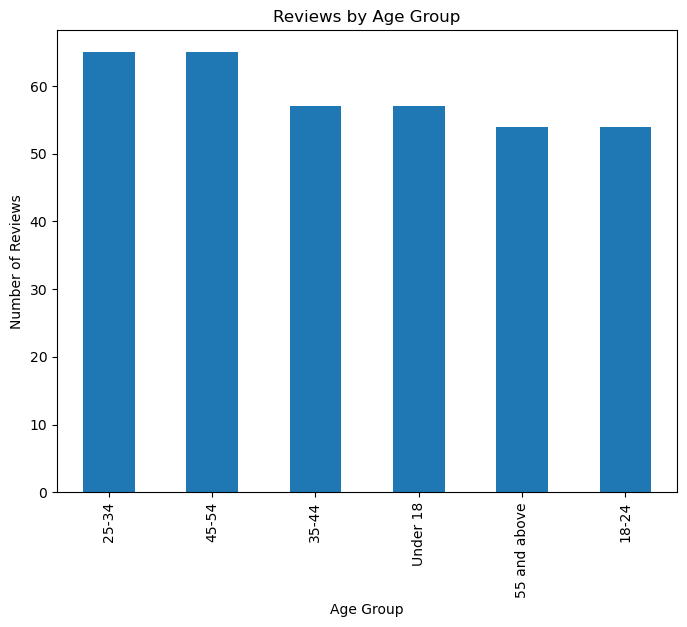

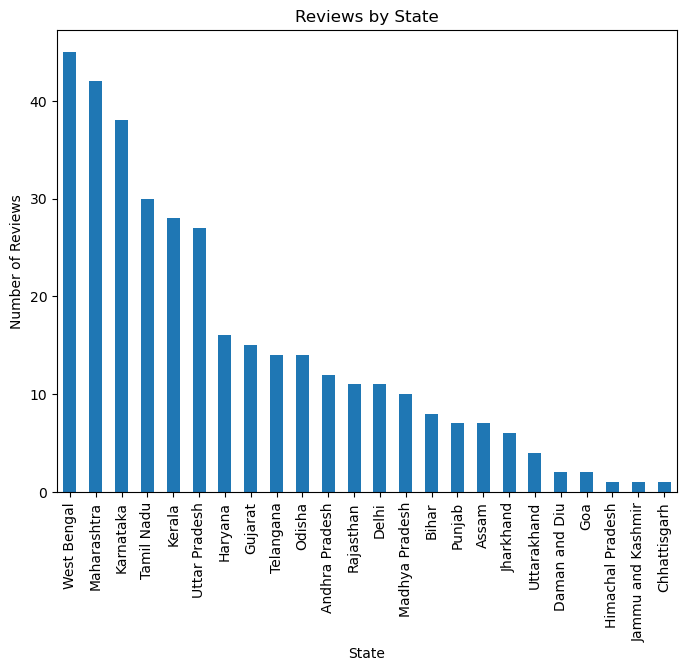

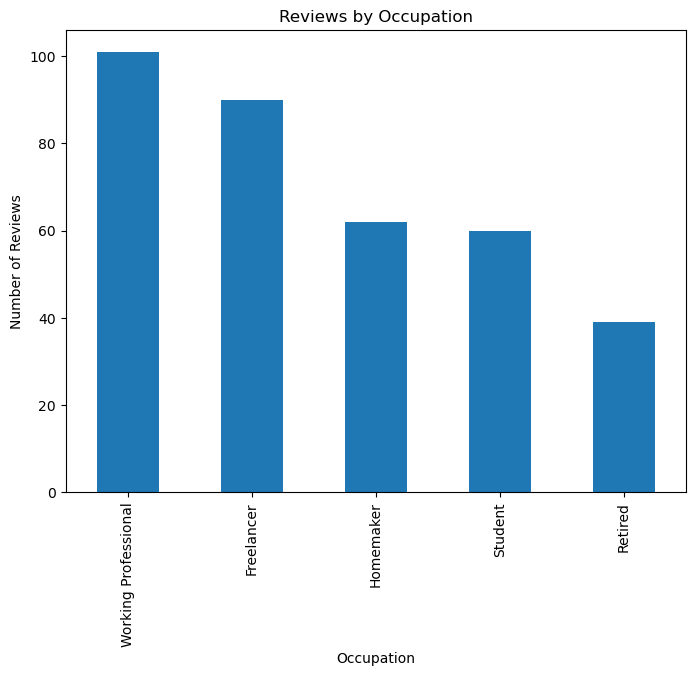

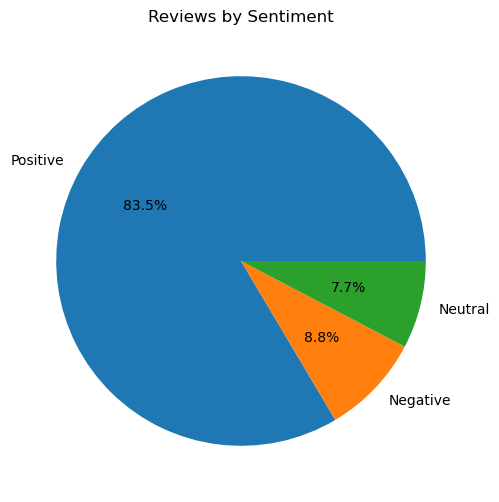

In [33]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df6)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df6[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)

# 3. Reviews by Location
reviews_by_state = df6[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df6[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df6[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(Mi)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Mi)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(Mi)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(Mi)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [125]:
df7 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df7.csv")
pd.DataFrame(df7)

,Reviews for Google Pixel Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I have been using Pixel Watch 2 from the last ...,25-34,M,"Ghaziabad, Uttar Pradesh",Freelancer,September,2024,Q3
1,Yet another overpriced amazing looking unique ...,45-54,F,"Bengaluru, Karnataka",Working Professional,December,2024,Q4
2,The watch looks very stylish and the features ...,Under 18,F,"Miryalaguda, Telangana",Student,March,2020,Q1
3,Cool 😎 watch,45-54,M,"Canacona, Goa",Freelancer,October,2022,Q4
4,The amoled display and overall built are absol...,Under 18,M,"Irinjalakuda, Kerala",Student,January,2021,Q1
...,...,...,...,...,...,...,...,...
65,Perfect,25-34,F,"Patna, Bihar",Homemaker,December,2023,Q4
66,Top Notch!!!!!! ❤️,35-44,F,"Lucknow, Uttar Pradesh",Working Professional,January,2023,Q1
67,"Costly, but totally worth it. The AMOLED displ...",45-54,F,"Mumbai, Maharashtra",Homemaker,June,2021,Q2
68,This is the best watch from Google and is mile...,Under 18,M,"Kolkata, West Bengal",Student,June,2023,Q2


In [127]:
df7.columns = df7.columns.str.strip()
review_column = "Reviews for Google Pixel Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df7[['Polarity', 'Sentiment']] = df7[review_column].apply(analyze_sentiment)
print(df7.head())

                      Reviews for Google Pixel Watch       Age Gender  \
0  I have been using Pixel Watch 2 from the last ...     25-34      M   
1  Yet another overpriced amazing looking unique ...     45-54      F   
2  The watch looks very stylish and the features ...  Under 18      F   
3                                       Cool 😎 watch     45-54      M   
4  The amoled display and overall built are absol...  Under 18      M   

                    Location            Occupation      Month  Year Quarter  \
0   Ghaziabad, Uttar Pradesh            Freelancer  September  2024      Q3   
1       Bengaluru, Karnataka  Working Professional   December  2024      Q4   
2     Miryalaguda, Telangana               Student      March  2020      Q1   
3              Canacona, Goa            Freelancer    October  2022      Q4   
4       Irinjalakuda, Kerala               Student    January  2021      Q1   

   Polarity Sentiment  
0  0.370370  Positive  
1  0.558333  Positive  
2  0.825000  P

In [129]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df7['state'] = df7['Location'].astype(str).apply(extract_state)
df7

,Reviews for Google Pixel Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I have been using Pixel Watch 2 from the last ...,25-34,M,"Ghaziabad, Uttar Pradesh",Freelancer,September,2024,Q3,0.370370,Positive,Uttar Pradesh
1,Yet another overpriced amazing looking unique ...,45-54,F,"Bengaluru, Karnataka",Working Professional,December,2024,Q4,0.558333,Positive,Karnataka
2,The watch looks very stylish and the features ...,Under 18,F,"Miryalaguda, Telangana",Student,March,2020,Q1,0.825000,Positive,Telangana
3,Cool 😎 watch,45-54,M,"Canacona, Goa",Freelancer,October,2022,Q4,0.350000,Positive,Goa
4,The amoled display and overall built are absol...,Under 18,M,"Irinjalakuda, Kerala",Student,January,2021,Q1,0.456061,Positive,Kerala
...,...,...,...,...,...,...,...,...,...,...,...
65,Perfect,25-34,F,"Patna, Bihar",Homemaker,December,2023,Q4,1.000000,Positive,Bihar
66,Top Notch!!!!!! ❤️,35-44,F,"Lucknow, Uttar Pradesh",Working Professional,January,2023,Q1,1.000000,Positive,Uttar Pradesh
67,"Costly, but totally worth it. The AMOLED displ...",45-54,F,"Mumbai, Maharashtra",Homemaker,June,2021,Q2,0.300000,Positive,Maharashtra
68,This is the best watch from Google and is mile...,Under 18,M,"Kolkata, West Bengal",Student,June,2023,Q2,0.750000,Positive,West Bengal


Total Reviews: 70
Reviews by Age Group:
Age
25-34           16
45-54           14
18-24           12
35-44           12
55 and above     9
Under 18         7
Name: count, dtype: int64
Reviews by Gender:
Gender
M    52
F    18
Name: count, dtype: int64
Reviews by State:
state
Karnataka         10
Maharashtra       10
Uttar Pradesh      8
West Bengal        7
Haryana            5
Delhi              4
Tamil Nadu         4
Andhra Pradesh     4
Telangana          4
Jharkhand          3
Punjab             3
Kerala             2
Uttarakhand        1
Goa                1
Madhya Pradesh     1
Gujarat            1
Odisha             1
Bihar              1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    24
Freelancer              21
Homemaker               10
Retired                  8
Student                  7
Name: count, dtype: int64
Reviews by Sentiment:
Sentiment
Positive    60
Neutral      5
Negative     5
Name: count, dtype: int64


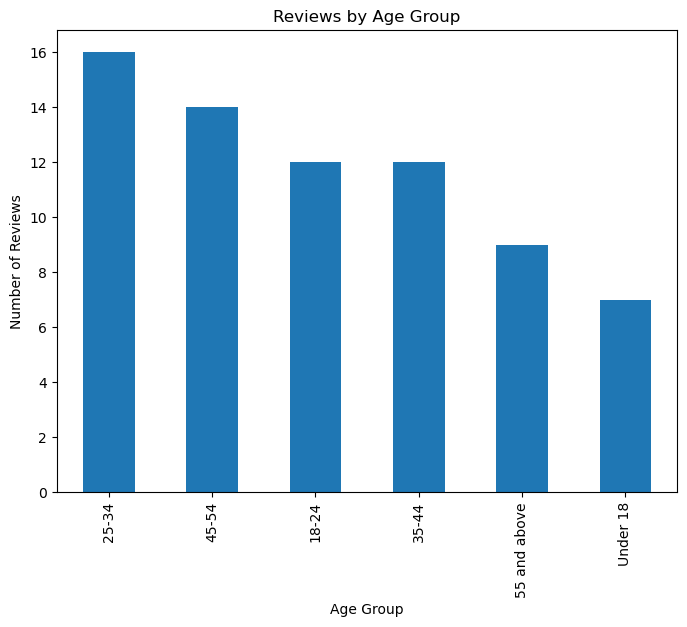

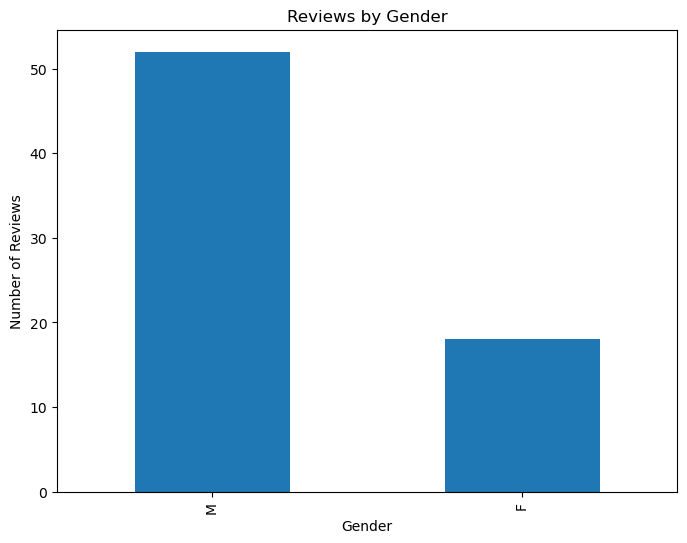

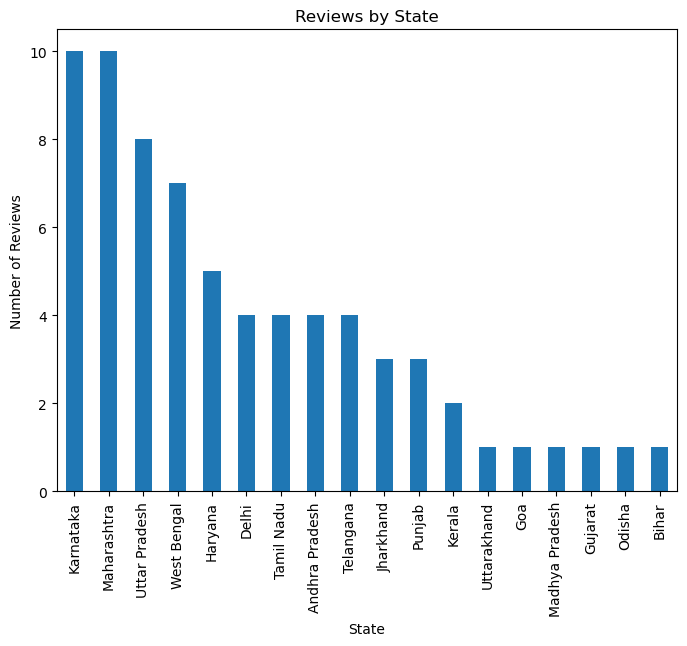

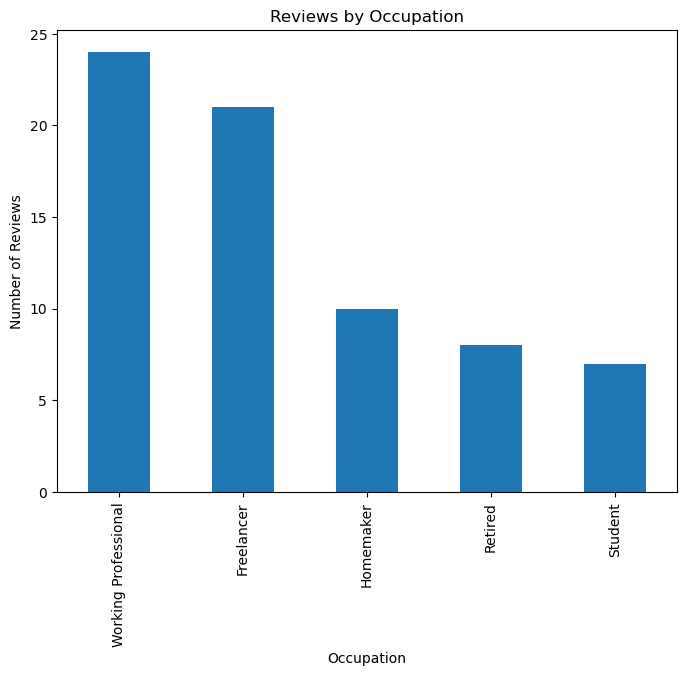

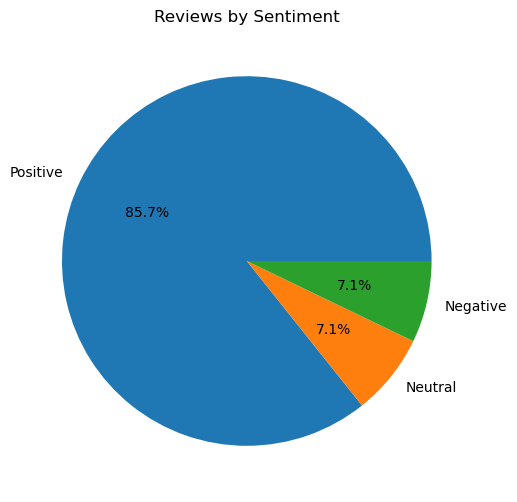

In [101]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df7)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df7[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df7[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender)

# 3. Reviews by Location
reviews_by_state = df7[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df7[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df7[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(Google)[Usage Analysis].png")

plt.show()
plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Google)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Google)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(Google)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(Google)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [133]:
df8 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df8.csv")
pd.DataFrame(df8)

,Reviews for Boat,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Boat smart watch is an impressive wearable dev...,Under 18,F,"Gauri Bazar, Uttar Pradesh",Student,July,2020,Q3
1,Product is very good 😊 love it,35-44,F,"Varanasi, Uttar Pradesh",Homemaker,March,2024,Q1
2,My friend tell about this it was so good produ...,18-24,F,"Madanapalle, Andhra Pradesh",Working Professional,November,2022,Q4
3,U have to charge Daily Or Every 2 Days . . . B...,35-44,M,"Surat, Gujarat",Working Professional,March,2024,Q1
4,Thnkss flipkart..,45-54,F,"Firozabad, Uttar Pradesh",Homemaker,February,2024,Q1
...,...,...,...,...,...,...,...,...
576,Noice,35-44,F,"Teleni Para, West Bengal",Homemaker,October,2020,Q4
577,"Cheating, there is no 100+cloud watch faces on...",55 and above,M,"Latur, Maharashtra",Retired,March,2023,Q1
578,Very nice,18-24,M,"Mumbai, Maharashtra",Freelancer,December,2021,Q4
579,Battery full charge working only 8 hours,Under 18,M,"Ambala, Haryana",Student,September,2023,Q3


In [135]:
df8.columns = df8.columns.str.strip()
review_column = "Reviews for Boat"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df8[['Polarity', 'Sentiment']] = df8[review_column].apply(analyze_sentiment)
print(df8.head())

                                    Reviews for Boat       Age Gender  \
0  Boat smart watch is an impressive wearable dev...  Under 18      F   
1                     Product is very good 😊 love it     35-44      F   
2  My friend tell about this it was so good produ...     18-24      F   
3  U have to charge Daily Or Every 2 Days . . . B...     35-44      M   
4                                  Thnkss flipkart..     45-54      F   

                       Location            Occupation     Month  Year Quarter  \
0    Gauri Bazar, Uttar Pradesh               Student      July  2020      Q3   
1       Varanasi, Uttar Pradesh             Homemaker     March  2024      Q1   
2   Madanapalle, Andhra Pradesh  Working Professional  November  2022      Q4   
3                Surat, Gujarat  Working Professional     March  2024      Q1   
4      Firozabad, Uttar Pradesh             Homemaker  February  2024      Q1   

   Polarity Sentiment  
0  0.280612  Positive  
1  0.705000  Positive  
2 

In [136]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df8['state'] = df8['Location'].astype(str).apply(extract_state)
df8

,Reviews for Boat,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Boat smart watch is an impressive wearable dev...,Under 18,F,"Gauri Bazar, Uttar Pradesh",Student,July,2020,Q3,0.280612,Positive,Uttar Pradesh
1,Product is very good 😊 love it,35-44,F,"Varanasi, Uttar Pradesh",Homemaker,March,2024,Q1,0.705000,Positive,Uttar Pradesh
2,My friend tell about this it was so good produ...,18-24,F,"Madanapalle, Andhra Pradesh",Working Professional,November,2022,Q4,0.700000,Positive,Andhra Pradesh
3,U have to charge Daily Or Every 2 Days . . . B...,35-44,M,"Surat, Gujarat",Working Professional,March,2024,Q1,0.031250,Positive,Gujarat
4,Thnkss flipkart..,45-54,F,"Firozabad, Uttar Pradesh",Homemaker,February,2024,Q1,0.000000,Neutral,Uttar Pradesh
...,...,...,...,...,...,...,...,...,...,...,...
576,Noice,35-44,F,"Teleni Para, West Bengal",Homemaker,October,2020,Q4,0.000000,Neutral,West Bengal
577,"Cheating, there is no 100+cloud watch faces on...",55 and above,M,"Latur, Maharashtra",Retired,March,2023,Q1,-0.108333,Negative,Maharashtra
578,Very nice,18-24,M,"Mumbai, Maharashtra",Freelancer,December,2021,Q4,0.780000,Positive,Maharashtra
579,Battery full charge working only 8 hours,Under 18,M,"Ambala, Haryana",Student,September,2023,Q3,0.175000,Positive,Haryana


In [113]:
df8 = df8[df8['state'] != 'Maharshtra']
df8 = df8[df8['state'] != 'West bengal']

Total Reviews: 579
Reviews by Age Group:
Age
18-24           111
35-44           109
45-54            99
25-34            95
Under 18         89
55 and above     76
Name: count, dtype: int64
Reviews by Gender:
Gender
M    385
F    194
Name: count, dtype: int64
Reviews by State:
state
Uttar Pradesh        98
West Bengal          81
Maharashtra          68
Madhya Pradesh       43
Bihar                33
Delhi                27
Gujarat              26
Karnataka            23
Odisha               22
Rajasthan            20
Tamil Nadu           20
Haryana              19
Jharkhand            18
Telangana            16
Kerala               15
Chhattisgarh         10
Assam                 9
Andhra Pradesh        9
Punjab                7
Uttarakhand           5
Arunachal Pradesh     2
Jammu and Kashmir     2
Himachal Pradesh      2
Meghalaya             1
Daman and Diu         1
Puducherry            1
Manipur               1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working

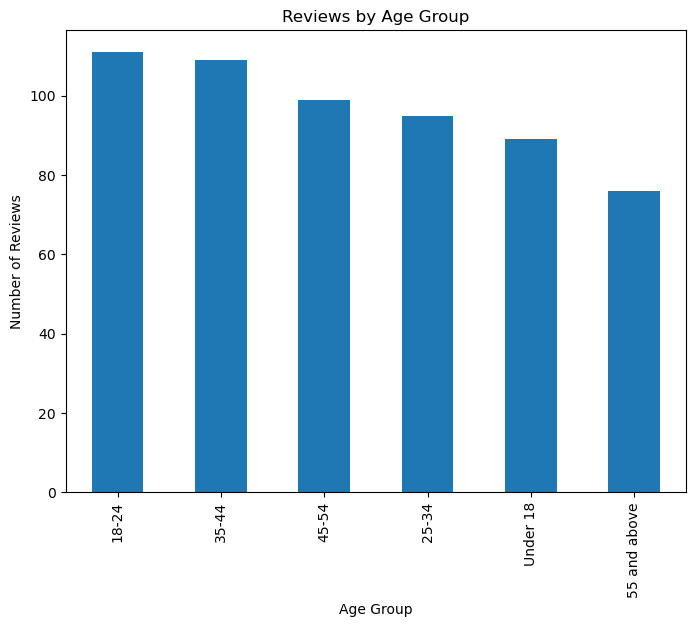

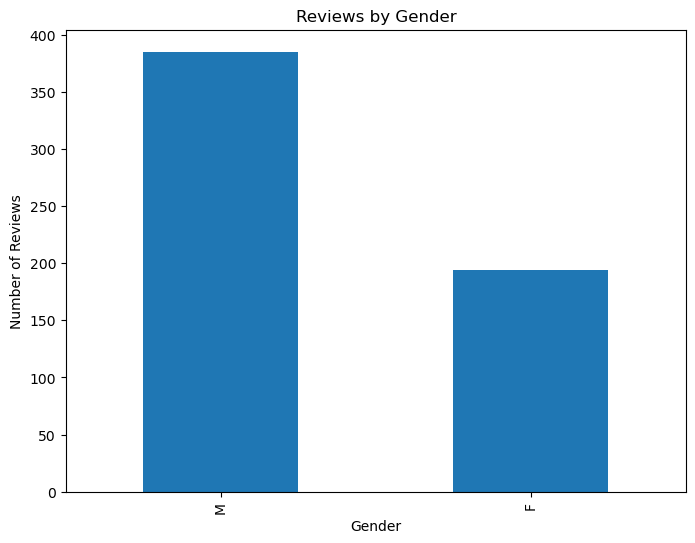

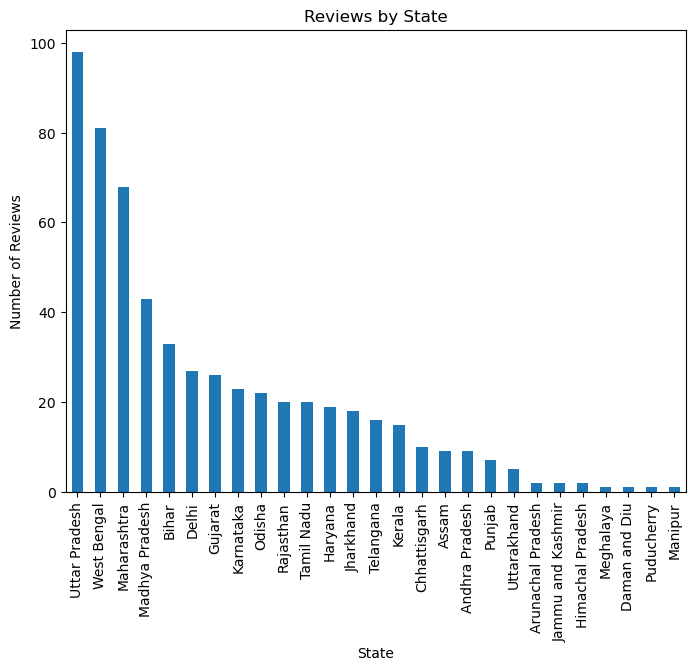

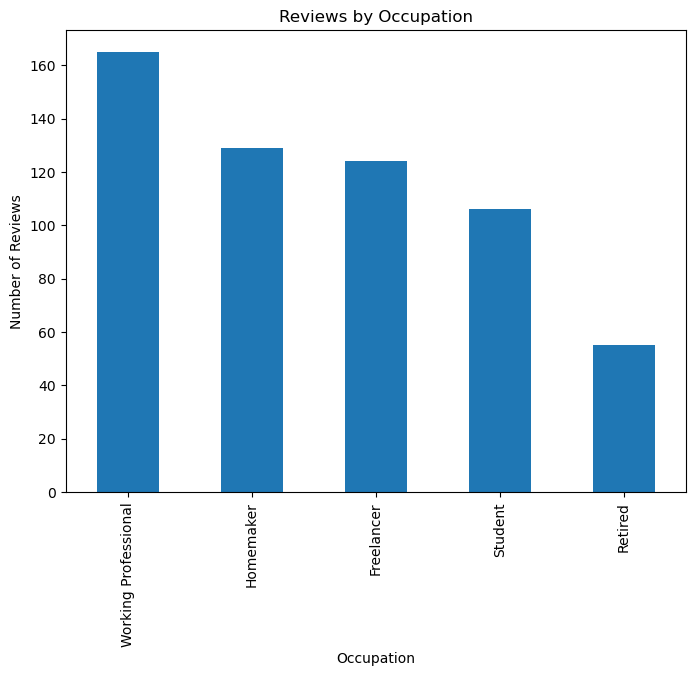

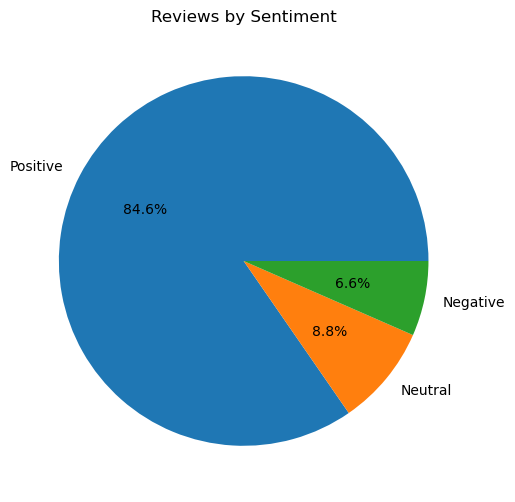

In [117]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df8)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df8[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df8[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender)

# 3. Reviews by Location
reviews_by_state = df8[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df8[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df8[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_Age(Boat)[Usage Analysis].png")
plt.show()
plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Boat)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Boat)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_Occupation(Boat)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(Boat)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [377]:
df9 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df9.csv")
pd.DataFrame(df9)

,Reviews for Fastrack,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Value for money ..thank you Fastrack,25-34,M,"East Godavari, Andhra Pradesh",Working Professional,February,2020,Q1
1,Nice quality,25-34,M,"Agra, Uttar Pradesh",Working Professional,March,2023,Q1
2,Good product,25-34,M,"Kolkata, West Bengal",Freelancer,April,2023,Q2
3,Thank you Flipkart ❣️\nBest Smartwatch for use...,35-44,M,"Purnia, Bihar",Working Professional,September,2022,Q3
4,Nice product,35-44,M,"Jamshedpur, Jharkhand",Working Professional,July,2024,Q3
...,...,...,...,...,...,...,...,...
687,Awesome 👍,45-54,M,"Jabalpur, Madhya Pradesh",Working Professional,January,2021,Q1
688,Product is good I love it,Under 18,F,"Chimakurthy, Andhra Pradesh",Student,November,2024,Q4
689,Good quality thanks for flipkart,45-54,F,"Medchal Malkajgiri District, Telangana",Homemaker,October,2024,Q4
690,Good p,18-24,M,"Berhampur, Odisha",Freelancer,June,2023,Q2


In [379]:
df9.columns = df9.columns.str.strip()
review_column = "Reviews for Fastrack"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df9[['Polarity', 'Sentiment']] = df9[review_column].apply(analyze_sentiment)
print(df9.head())

                                Reviews for Fastrack    Age Gender  \
0               Value for money ..thank you Fastrack  25-34      M   
1                                       Nice quality  25-34      M   
2                                       Good product  25-34      M   
3  Thank you Flipkart ❣️\nBest Smartwatch for use...  35-44      M   
4                                       Nice product  35-44      M   

                         Location            Occupation      Month  Year  \
0   East Godavari, Andhra Pradesh  Working Professional   February  2020   
1             Agra, Uttar Pradesh  Working Professional      March  2023   
2            Kolkata, West Bengal            Freelancer      April  2023   
3                  Purnia, Bihar   Working Professional  September  2022   
4           Jamshedpur, Jharkhand  Working Professional       July  2024   

  Quarter  Polarity Sentiment  
0      Q1    0.0000   Neutral  
1      Q1    0.6000  Positive  
2      Q2    0.7000  Posit

In [382]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df9['state'] = df9['Location'].astype(str).apply(extract_state)
df9

,Reviews for Fastrack,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Value for money ..thank you Fastrack,25-34,M,"East Godavari, Andhra Pradesh",Working Professional,February,2020,Q1,0.0000,Neutral,Andhra Pradesh
1,Nice quality,25-34,M,"Agra, Uttar Pradesh",Working Professional,March,2023,Q1,0.6000,Positive,Uttar Pradesh
2,Good product,25-34,M,"Kolkata, West Bengal",Freelancer,April,2023,Q2,0.7000,Positive,West Bengal
3,Thank you Flipkart ❣️\nBest Smartwatch for use...,35-44,M,"Purnia, Bihar",Working Professional,September,2022,Q3,0.4375,Positive,Bihar
4,Nice product,35-44,M,"Jamshedpur, Jharkhand",Working Professional,July,2024,Q3,0.6000,Positive,Jharkhand
...,...,...,...,...,...,...,...,...,...,...,...
687,Awesome 👍,45-54,M,"Jabalpur, Madhya Pradesh",Working Professional,January,2021,Q1,1.0000,Positive,Madhya Pradesh
688,Product is good I love it,Under 18,F,"Chimakurthy, Andhra Pradesh",Student,November,2024,Q4,0.6000,Positive,Andhra Pradesh
689,Good quality thanks for flipkart,45-54,F,"Medchal Malkajgiri District, Telangana",Homemaker,October,2024,Q4,0.4500,Positive,Telangana
690,Good p,18-24,M,"Berhampur, Odisha",Freelancer,June,2023,Q2,0.7000,Positive,Odisha


In [383]:
df9 = df9[df9['state'] != 'Maharshtra']


Total Reviews: 691
Reviews by Age Group:
Age
35-44           125
45-54           122
Under 18        115
25-34           111
18-24           110
55 and above    108
Name: count, dtype: int64
Reviews by State:
state
West Bengal          111
Maharashtra           71
Uttar Pradesh         67
Karnataka             53
Bihar                 44
Tamil Nadu            42
Madhya Pradesh        36
Odisha                36
Andhra Pradesh        32
Gujarat               30
Telangana             29
Rajasthan             26
Kerala                22
Delhi                 20
Jharkhand             14
Punjab                13
Haryana               12
Assam                  9
Uttarakhand            6
Chhattisgarh           5
Goa                    3
Himachal Pradesh       3
Sikkim                 3
Tripura                2
Jammu and Kashmir      1
Mizoram                1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    196
Freelancer              166
Homemaker          

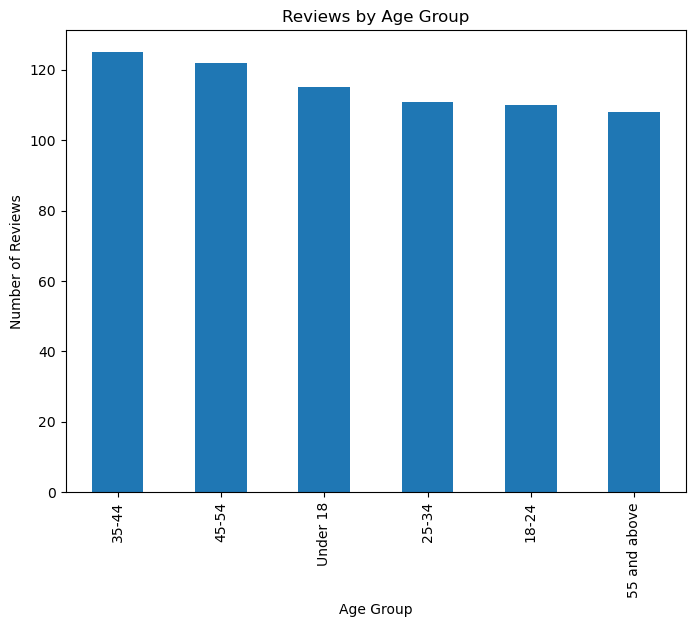

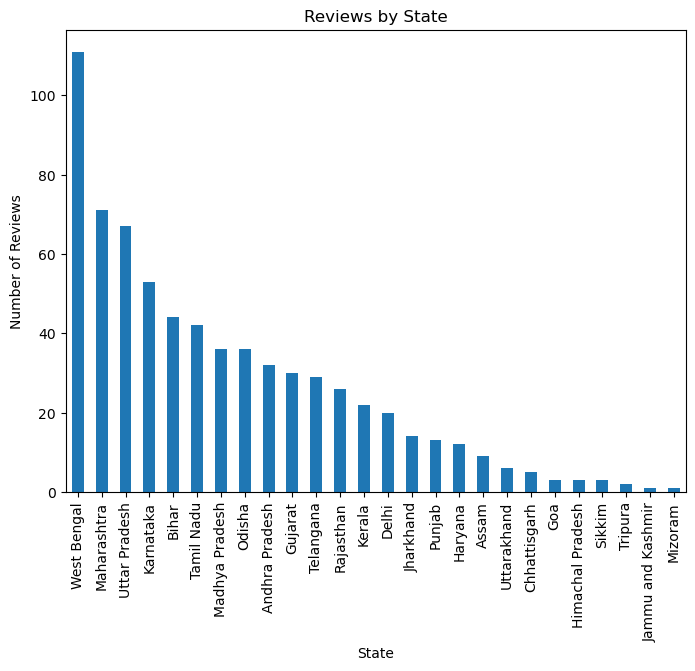

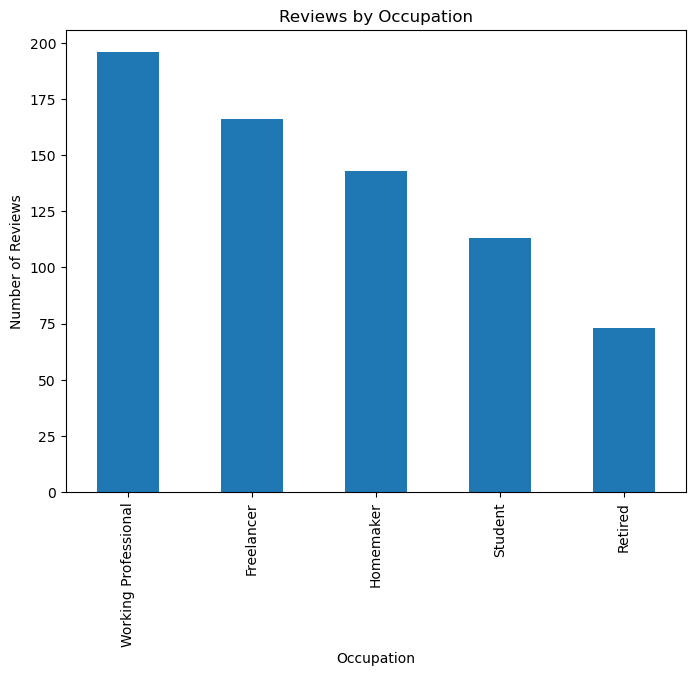

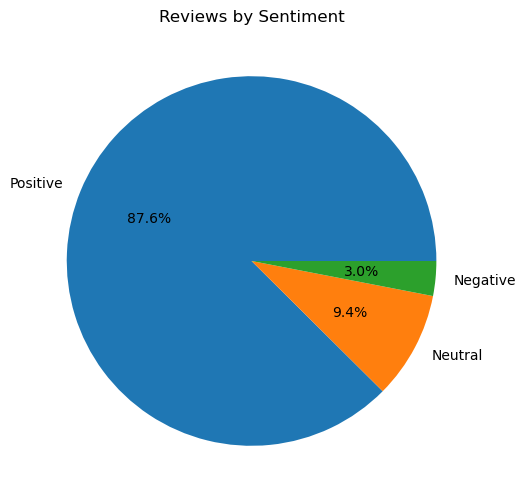

In [384]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df9)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df9[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)

# 3. Reviews by Location
reviews_by_state = df9[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df9[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df9[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [13]:
df10 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df10.csv")
pd.DataFrame(df10)

,Reviews for Fireboltt,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I am using it from a day. It's really good loo...,25-34,M,"Tumkur, Karnataka",Working Professional,November,2024,Q4
1,Nice watch' good deal thnx Flipkart\nI need on...,55 and above,M,"Mumbai, Maharashtra",Retired,May,2023,Q2
2,"Very nice, I have bought for child, he so mush...",25-34,F,"Kanpur, Uttar Pradesh",Homemaker,December,2024,Q4
3,Superb i m impressed,25-34,F,"Chennai, Tamil Nadu",Homemaker,April,2021,Q2
4,Loved it,35-44,M,"New Town, West Bengal",Freelancer,January,2020,Q1
...,...,...,...,...,...,...,...,...
908,We can't call anyone through Bluetooth.But we ...,45-54,F,"Kanjiramkulam, Kerala",Homemaker,August,2020,Q3
909,Good watch,Under 18,M,"Vadodara, Gujarat",Student,August,2022,Q3
910,Very nice ✅✅product,18-24,M,"Ranchi, Jharkhand",Freelancer,April,2023,Q2
911,This to good for the money I paid,Under 18,M,"Bengaluru, Karnataka",Student,June,2021,Q2


In [15]:
df10.columns = df10.columns.str.strip()
review_column = "Reviews for Fireboltt"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df10[['Polarity', 'Sentiment']] = df10[review_column].apply(analyze_sentiment)
print(df10.head())

                               Reviews for Fireboltt           Age Gender  \
0  I am using it from a day. It's really good loo...         25-34      M   
1  Nice watch' good deal thnx Flipkart\nI need on...  55 and above      M   
2  Very nice, I have bought for child, he so mush...         25-34      F   
3                               Superb i m impressed         25-34      F   
4                                           Loved it         35-44      M   

                 Location            Occupation     Month  Year Quarter  \
0       Tumkur, Karnataka  Working Professional  November  2024      Q4   
1     Mumbai, Maharashtra               Retired       May  2023      Q2   
2   Kanpur, Uttar Pradesh             Homemaker  December  2024      Q4   
3     Chennai, Tamil Nadu             Homemaker     April  2021      Q2   
4   New Town, West Bengal            Freelancer   January  2020      Q1   

   Polarity Sentiment  
0  0.788333  Positive  
1  0.682000  Positive  
2  0.780000  P

In [16]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df10['state'] = df10['Location'].astype(str).apply(extract_state)
df10

,Reviews for Fireboltt,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I am using it from a day. It's really good loo...,25-34,M,"Tumkur, Karnataka",Working Professional,November,2024,Q4,0.788333,Positive,Karnataka
1,Nice watch' good deal thnx Flipkart\nI need on...,55 and above,M,"Mumbai, Maharashtra",Retired,May,2023,Q2,0.682000,Positive,Maharashtra
2,"Very nice, I have bought for child, he so mush...",25-34,F,"Kanpur, Uttar Pradesh",Homemaker,December,2024,Q4,0.780000,Positive,Uttar Pradesh
3,Superb i m impressed,25-34,F,"Chennai, Tamil Nadu",Homemaker,April,2021,Q2,1.000000,Positive,Tamil Nadu
4,Loved it,35-44,M,"New Town, West Bengal",Freelancer,January,2020,Q1,0.700000,Positive,West Bengal
...,...,...,...,...,...,...,...,...,...,...,...
908,We can't call anyone through Bluetooth.But we ...,45-54,F,"Kanjiramkulam, Kerala",Homemaker,August,2020,Q3,0.150000,Positive,Kerala
909,Good watch,Under 18,M,"Vadodara, Gujarat",Student,August,2022,Q3,0.700000,Positive,Gujarat
910,Very nice ✅✅product,18-24,M,"Ranchi, Jharkhand",Freelancer,April,2023,Q2,0.780000,Positive,Jharkhand
911,This to good for the money I paid,Under 18,M,"Bengaluru, Karnataka",Student,June,2021,Q2,0.700000,Positive,Karnataka


In [19]:
df10 = df10[df10['state'] != 'Maharshtra']
df10 = df10[df10['state'] != 'Maharashtraa']
df10 = df10[df10['Occupation'] != 'R']

Total Reviews: 910
Reviews by Age Group:
Age
18-24           166
25-34           156
Under 18        153
55 and above    151
45-54           150
35-44           134
Name: count, dtype: int64
Reviews by Gender:
Gender
M    592
F    318
Name: count, dtype: int64
Reviews by State:
state
Maharashtra          130
Uttar Pradesh        105
West Bengal           92
Karnataka             81
Tamil Nadu            68
Bihar                 55
Andhra Pradesh        50
Telangana             48
Gujarat               37
Kerala                35
Odisha                31
Haryana               28
Rajasthan             26
Delhi                 26
Madhya Pradesh        25
Assam                 16
Jharkhand             12
Punjab                11
Chhattisgarh           7
Uttarakhand            6
Goa                    5
Himachal Pradesh       4
Jammu and Kashmir      3
Tripura                2
Puducherry             2
Daman and Diu          2
Sikkim                 1
Meghalaya              1
Odiisha        

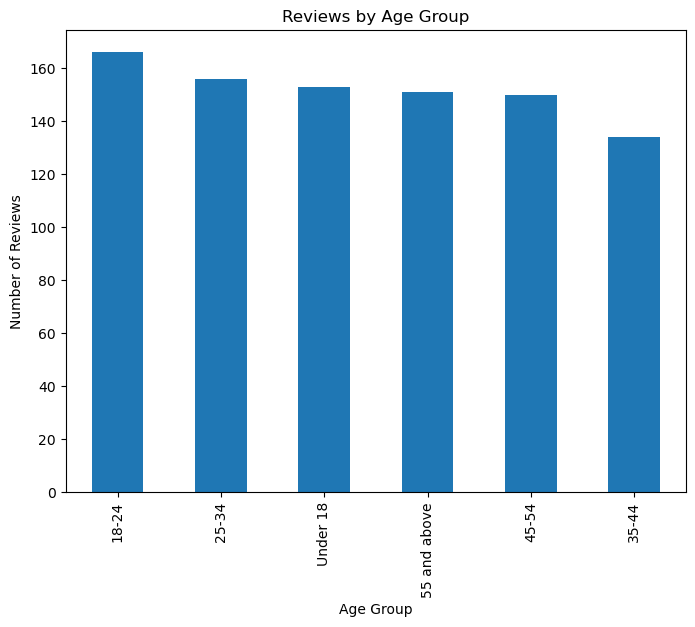

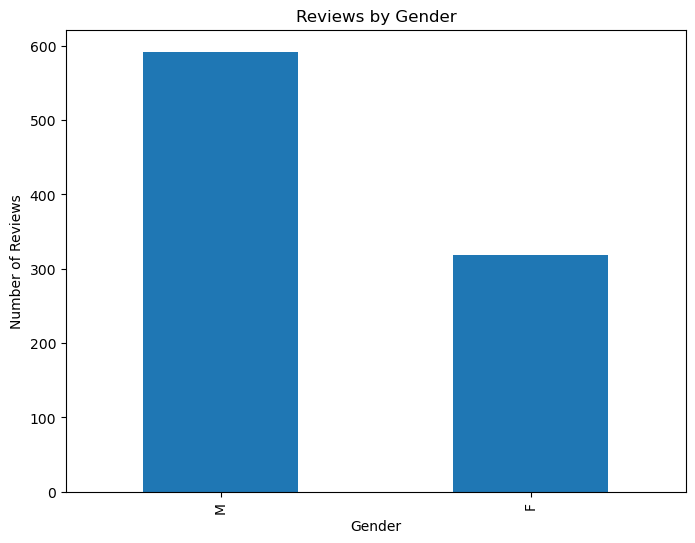

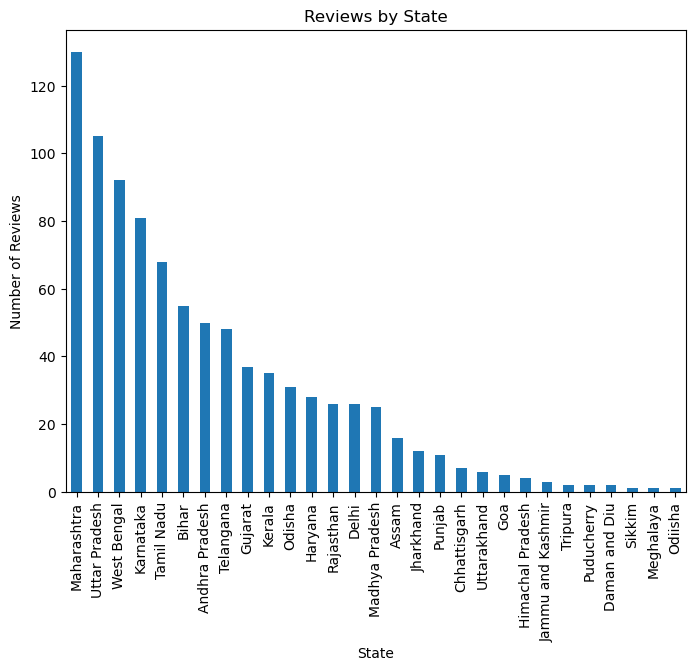

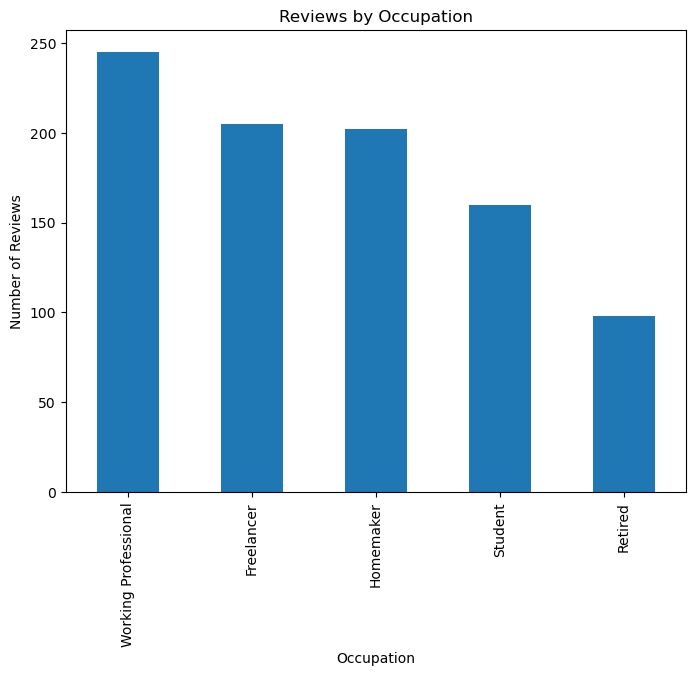

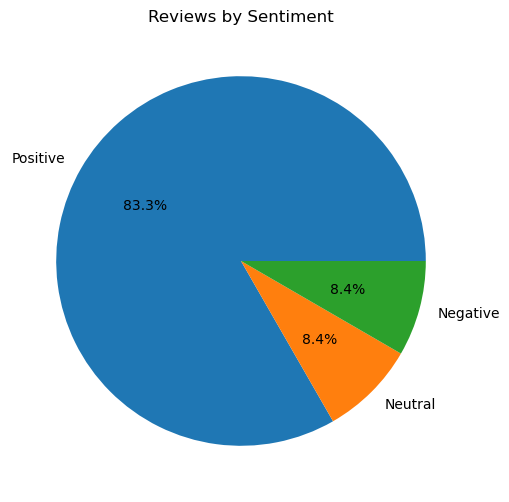

In [21]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df10)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df10[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df10[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender)

# 3. Reviews by Location
reviews_by_state = df10[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df10[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df10[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_age(Fireboltt)[Usage Analysis].png")
plt.show()
plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Fireboltt)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Fireboltt)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_occupation(Fireboltt)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("Overall_sentiment(Fireboltt)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [25]:
df11 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df11.csv")
pd.DataFrame(df11)

,Reviews for FitBit,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I wasn't a great fan of activity monitors but ...,25-34,F,"Hyderabad, Telangana",Homemaker,May,2022,Q2
1,My wife wanted a smart watch which could guess...,55 and above,M,"Udupi, Karnataka",Retired,July,2023,Q3
2,"Overall the look and the features are good, ho...",35-44,F,"Kolkata, West Bengal",Homemaker,February,2021,Q1
3,Every day I am falling in love with this versa...,25-34,F,"Kanakapura, Karnataka",Homemaker,July,2024,Q3
4,wonderful product,55 and above,M,"Mahindra World City, Tamil Nadu",Student,November,2021,Q4
...,...,...,...,...,...,...,...,...
296,Very good smart watch..,35-44,M,"Dharapuram, Tamil Nadu",Working Professional,November,2022,Q4
297,Great,55 and above,F,"Ludhiana, Punjab",Homemaker,March,2021,Q1
298,Excellent watch..\nWorth to buy,Under 18,F,"Raman, Punjab",Student,July,2022,Q3
299,please don't go for versa 3. The watch softwar...,18-24,F,"Thiruvananthapuram, Kerala",Working Professional,April,2021,Q2


In [27]:
df11.columns = df11.columns.str.strip()
review_column = "Reviews for FitBit"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df11[['Polarity', 'Sentiment']] = df11[review_column].apply(analyze_sentiment)
print(df11.head())

                                  Reviews for FitBit           Age Gender  \
0  I wasn't a great fan of activity monitors but ...         25-34      F   
1  My wife wanted a smart watch which could guess...  55 and above      M   
2  Overall the look and the features are good, ho...         35-44      F   
3  Every day I am falling in love with this versa...         25-34      F   
4                                  wonderful product  55 and above      M   

                           Location Occupation     Month  Year Quarter  \
0              Hyderabad, Telangana  Homemaker       May  2022      Q2   
1                  Udupi, Karnataka    Retired      July  2023      Q3   
2              Kolkata, West Bengal  Homemaker  February  2021      Q1   
3             Kanakapura, Karnataka  Homemaker      July  2024      Q3   
4   Mahindra World City, Tamil Nadu    Student  November  2021      Q4   

   Polarity Sentiment  
0  0.290741  Positive  
1  0.082857  Positive  
2  0.190152  Positiv

In [28]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df11['state'] = df11['Location'].astype(str).apply(extract_state)
df11

,Reviews for FitBit,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I wasn't a great fan of activity monitors but ...,25-34,F,"Hyderabad, Telangana",Homemaker,May,2022,Q2,0.290741,Positive,Telangana
1,My wife wanted a smart watch which could guess...,55 and above,M,"Udupi, Karnataka",Retired,July,2023,Q3,0.082857,Positive,Karnataka
2,"Overall the look and the features are good, ho...",35-44,F,"Kolkata, West Bengal",Homemaker,February,2021,Q1,0.190152,Positive,West Bengal
3,Every day I am falling in love with this versa...,25-34,F,"Kanakapura, Karnataka",Homemaker,July,2024,Q3,0.333333,Positive,Karnataka
4,wonderful product,55 and above,M,"Mahindra World City, Tamil Nadu",Student,November,2021,Q4,1.000000,Positive,Tamil Nadu
...,...,...,...,...,...,...,...,...,...,...,...
296,Very good smart watch..,35-44,M,"Dharapuram, Tamil Nadu",Working Professional,November,2022,Q4,0.562143,Positive,Tamil Nadu
297,Great,55 and above,F,"Ludhiana, Punjab",Homemaker,March,2021,Q1,0.800000,Positive,Punjab
298,Excellent watch..\nWorth to buy,Under 18,F,"Raman, Punjab",Student,July,2022,Q3,0.650000,Positive,Punjab
299,please don't go for versa 3. The watch softwar...,18-24,F,"Thiruvananthapuram, Kerala",Working Professional,April,2021,Q2,-0.225397,Negative,Kerala


In [31]:
df11 = df11[df11['state'] != 'Maharshtra']

Total Reviews: 300
Reviews by Age Group:
Age
18-24           58
Under 18        53
25-34           49
35-44           49
55 and above    46
45-54           45
Name: count, dtype: int64
Reviews by Gender:
Gender
M    200
F    100
Name: count, dtype: int64
Reviews by State:
state
Maharashtra          59
Karnataka            37
Telangana            30
Uttar Pradesh        19
Kerala               18
Delhi                17
West Bengal          16
Gujarat              14
Tamil Nadu           13
Haryana              12
Andhra Pradesh       11
Odisha                8
Punjab                8
Rajasthan             7
Madhya Pradesh        6
Jharkhand             5
Chhattisgarh          4
Uttarakhand           4
Bihar                 3
Goa                   2
Puducherry            2
Assam                 2
Tripura               1
Jammu and Kashmir     1
Himachal Pradesh      1
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    85
Freelancer              70
Homemak

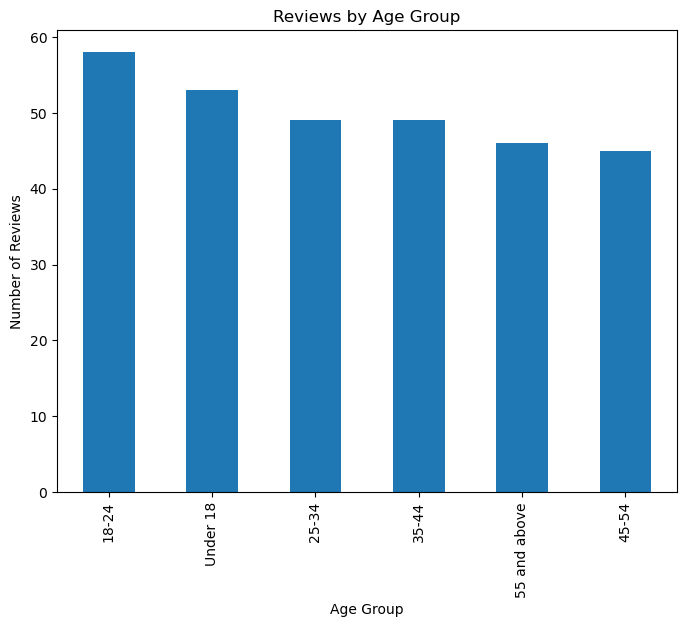

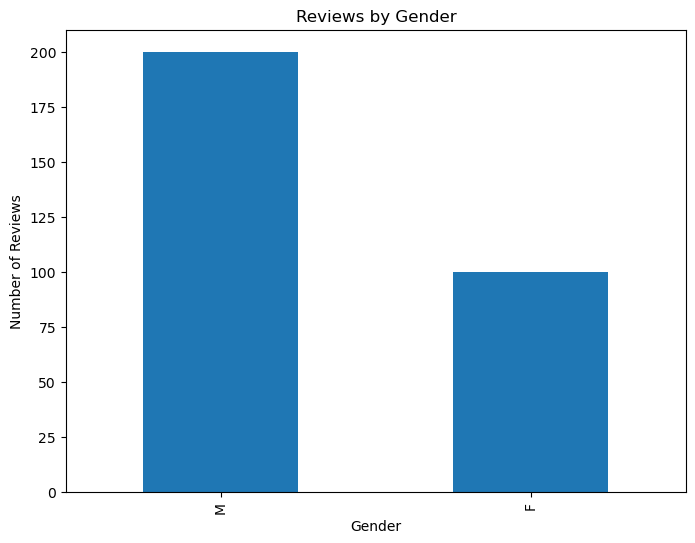

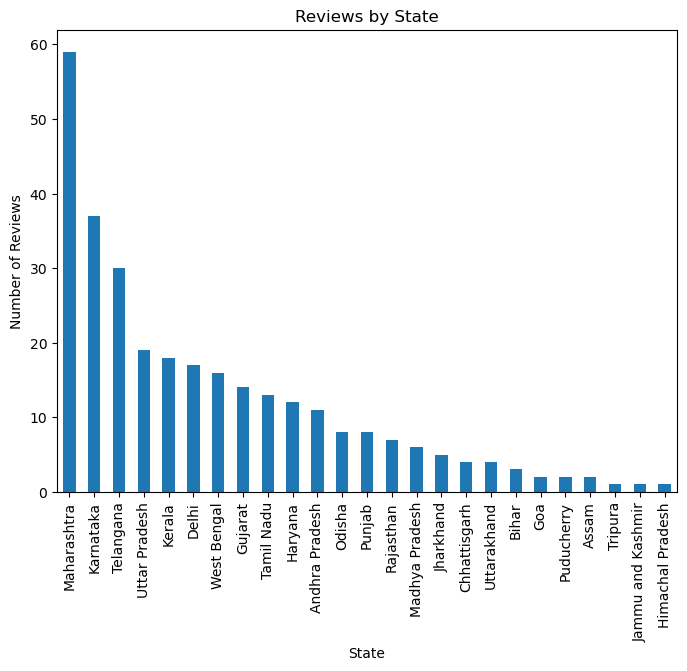

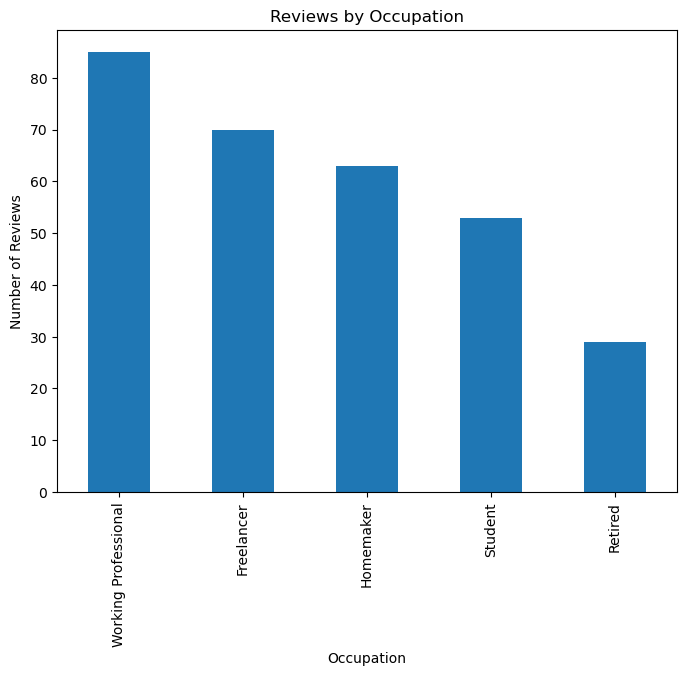

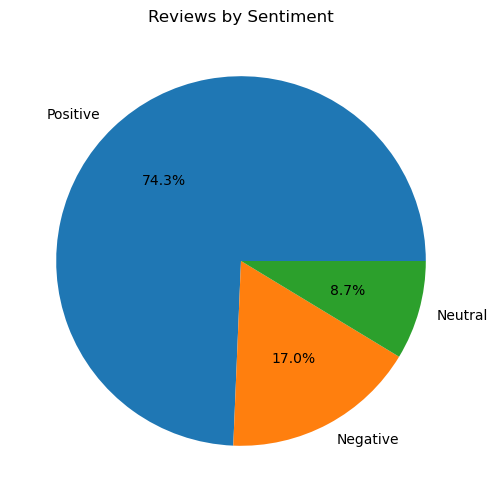

In [33]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
gender_column = "Gender"
age_column = "Age"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df11)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df11[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df11[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender)

# 3. Reviews by Location
reviews_by_state = df11[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df11[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df11[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_age(FitBit)[Usage Analysis].png")
plt.show()

plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(FitBit)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(FitBit)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_occupation(FitBit)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("overall_sentiment(FitBit)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [39]:
df12 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df12.csv")
pd.DataFrame(df12)

,Reviews for Boult,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Awesome watch with overloaded features. And it...,25-34,M,"Muzaffarnagar, Uttar Pradesh",Freelancer,January,2022,Q1
1,Good product and best Quality,25-34,M,"Raigarh, Chhattisgarh",Working Professional,August,2021,Q3
2,"Value For Money Product, But Battary Drain Ver...",25-34,M,"Kolhapur, Maharashtra",Working Professional,February,2021,Q1
3,Nice watch very happy 😊,55 and above,F,"Saharsa, Bihar",Homemaker,December,2022,Q4
4,Look wise very good features is decent as othe...,Under 18,F,"Buldhana, Maharashtra",Student,September,2024,Q3
...,...,...,...,...,...,...,...,...
693,Nice 👍,45-54,M,"Janjgir, Chhattisgarh",Working Professional,August,2021,Q3
694,Good product...,35-44,M,"South Twenty Four Parganas District, West Bengal",Working Professional,December,2022,Q4
695,Product is very good 👍😊\nHappy 😊,45-54,M,"Mumbai, Maharashtra",Working Professional,February,2020,Q1
696,Very good,55 and above,F,"Vijalpor, Gujarat",Homemaker,October,2024,Q4


In [41]:
df12.columns = df12.columns.str.strip()
review_column = "Reviews for Boult"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df12[['Polarity', 'Sentiment']] = df12[review_column].apply(analyze_sentiment)
print(df12.head())

                                   Reviews for Boult           Age Gender  \
0  Awesome watch with overloaded features. And it...         25-34      M   
1                      Good product and best Quality         25-34      M   
2  Value For Money Product, But Battary Drain Ver...         25-34      M   
3                            Nice watch very happy 😊  55 and above      F   
4  Look wise very good features is decent as othe...      Under 18      F   

                        Location            Occupation      Month  Year  \
0   Muzaffarnagar, Uttar Pradesh            Freelancer    January  2022   
1         Raigarh, Chhattisgarh   Working Professional     August  2021   
2          Kolhapur, Maharashtra  Working Professional   February  2021   
3                Saharsa, Bihar              Homemaker   December  2022   
4          Buldhana, Maharashtra               Student  September  2024   

  Quarter  Polarity Sentiment  
0      Q1  0.739333  Positive  
1      Q3  0.850000  P

In [42]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df12['state'] = df12['Location'].astype(str).apply(extract_state)
df12

,Reviews for Boult,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Awesome watch with overloaded features. And it...,25-34,M,"Muzaffarnagar, Uttar Pradesh",Freelancer,January,2022,Q1,0.739333,Positive,Uttar Pradesh
1,Good product and best Quality,25-34,M,"Raigarh, Chhattisgarh",Working Professional,August,2021,Q3,0.850000,Positive,Chhattisgarh
2,"Value For Money Product, But Battary Drain Ver...",25-34,M,"Kolhapur, Maharashtra",Working Professional,February,2021,Q1,0.268571,Positive,Maharashtra
3,Nice watch very happy 😊,55 and above,F,"Saharsa, Bihar",Homemaker,December,2022,Q4,0.800000,Positive,Bihar
4,Look wise very good features is decent as othe...,Under 18,F,"Buldhana, Maharashtra",Student,September,2024,Q3,0.412917,Positive,Maharashtra
...,...,...,...,...,...,...,...,...,...,...,...
693,Nice 👍,45-54,M,"Janjgir, Chhattisgarh",Working Professional,August,2021,Q3,0.600000,Positive,Chhattisgarh
694,Good product...,35-44,M,"South Twenty Four Parganas District, West Bengal",Working Professional,December,2022,Q4,0.700000,Positive,West Bengal
695,Product is very good 👍😊\nHappy 😊,45-54,M,"Mumbai, Maharashtra",Working Professional,February,2020,Q1,0.855000,Positive,Maharashtra
696,Very good,55 and above,F,"Vijalpor, Gujarat",Homemaker,October,2024,Q4,0.910000,Positive,Gujarat


In [45]:
df12 = df12[df12['state'] != 'Maharshtra']
df12 = df12[df12['state'] != 'West bengal']

Total Reviews: 695
Reviews by Age Group:
Age
55 and above    133
25-34           126
Under 18        121
35-44           111
18-24           106
45-54            98
Name: count, dtype: int64
Reviews by Gender:
Age
55 and above    133
25-34           126
Under 18        121
35-44           111
18-24           106
45-54            98
Name: count, dtype: int64
Reviews by State:
state
Maharashtra          95
Uttar Pradesh        76
West Bengal          76
Karnataka            59
Kerala               48
Bihar                42
Tamil Nadu           36
Delhi                33
Gujarat              28
Madhya Pradesh       28
Odisha               26
Telangana            24
Andhra Pradesh       24
Rajasthan            22
Jharkhand            18
Punjab               12
Assam                12
Chhattisgarh         11
Haryana              10
Uttarakhand           4
Tripura               4
Himachal Pradesh      2
Daman and Diu         2
Arunachal Pradesh     1
Jammu and Kashmir     1
Goa             

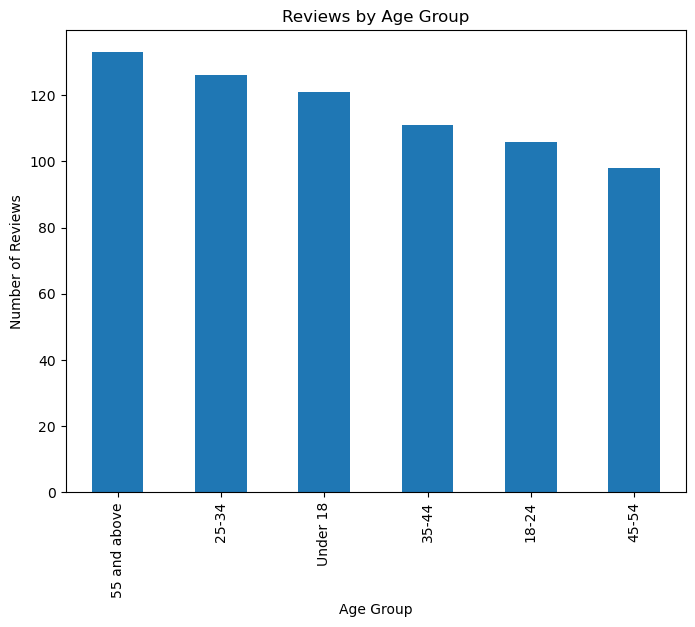

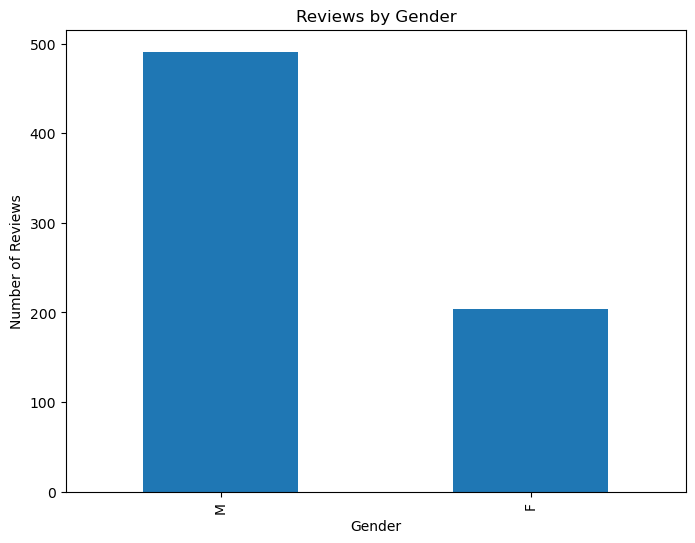

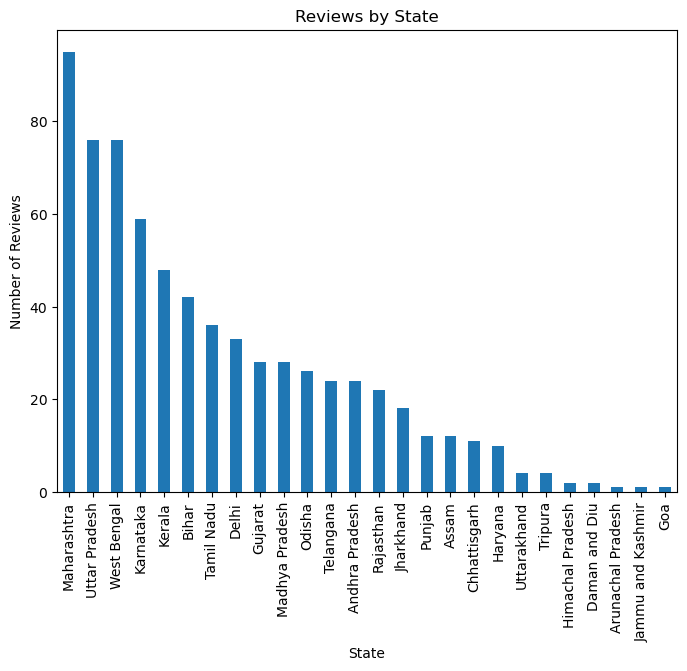

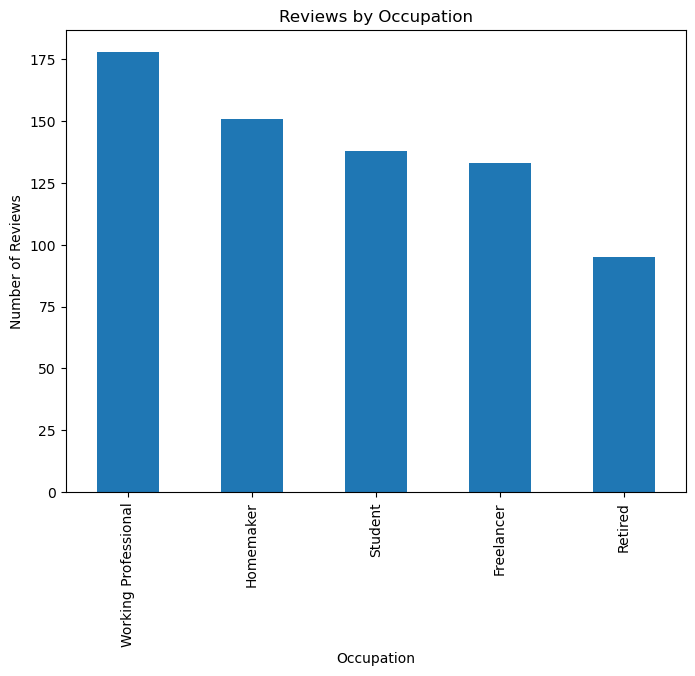

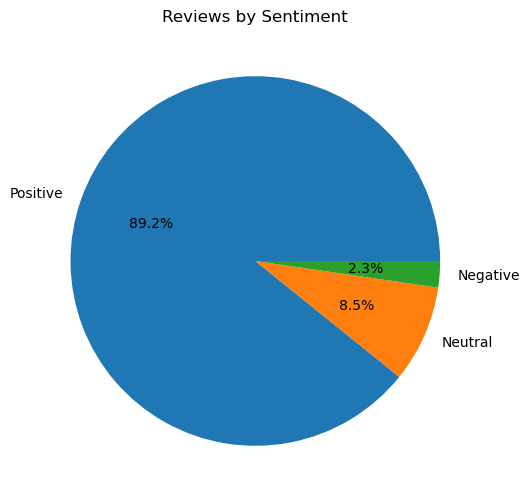

In [47]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df12)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df12[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df12[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_age_group)

# 3. Reviews by Location
reviews_by_state = df12[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df12[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df12[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_age(Boult)[Usage Analysis].png")

plt.show()
plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Boult)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Boult)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_occupation(Boult)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("overall_sentiment(Boult)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [51]:
df13 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df13.csv")
pd.DataFrame(df13)

,Reviews for Amazfit,Age,Gender,Location,Occupation,Month,Year,Quarter
0,It's not a watch but a sophisticated / premium...,18-24,M,"Indore, Madhya Pradesh",Working Professional,May,2021,Q2
1,Just awesome\nDisplay is very nice\nNo lagging...,55 and above,M,"Panihati, West Bengal",Retired,August,2021,Q3
2,Superb watch this watch is amazing\nRealme and...,18-24,M,"East Delhi, Delhi",Working Professional,August,2021,Q3
3,Bestest smartwatch ⌚ ever 😍\nI really liked it...,25-34,M,"Bara Banki, Jharkhand",Freelancer,April,2020,Q2
4,I love this watch ❤️❤️I buy for my sister she ...,25-34,F,"Ullal, Karnataka",Homemaker,July,2022,Q3
...,...,...,...,...,...,...,...,...
589,One of the best smart watch. Top notch quality...,45-54,M,"Hoshiarpur, Punjab",Freelancer,August,2020,Q3
590,"When I bought it my first impression was good,...",55 and above,M,"Dimapur, Nagaland",Retired,February,2022,Q1
591,I liked the product. Straps should be of leath...,35-44,M,"Jammu, Jammu and Kashmir",Working Professional,November,2024,Q4
592,Style and Performance watch.,35-44,F,"Hyderabad, Telangana",Homemaker,September,2023,Q3


In [53]:
df13.columns = df13.columns.str.strip()
review_column = "Reviews for Amazfit"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df13[['Polarity', 'Sentiment']] = df13[review_column].apply(analyze_sentiment)
print(df13.head())

                                 Reviews for Amazfit           Age Gender  \
0  It's not a watch but a sophisticated / premium...         18-24      M   
1  Just awesome\nDisplay is very nice\nNo lagging...  55 and above      M   
2  Superb watch this watch is amazing\nRealme and...         18-24      M   
3  Bestest smartwatch ⌚ ever 😍\nI really liked it...         25-34      M   
4  I love this watch ❤️❤️I buy for my sister she ...         25-34      F   

                  Location            Occupation   Month  Year Quarter  \
0   Indore, Madhya Pradesh  Working Professional     May  2021      Q2   
1    Panihati, West Bengal               Retired  August  2021      Q3   
2        East Delhi, Delhi  Working Professional  August  2021      Q3   
3    Bara Banki, Jharkhand            Freelancer   April  2020      Q2   
4         Ullal, Karnataka             Homemaker    July  2022      Q3   

   Polarity Sentiment  
0  0.250693  Positive  
1  0.726667  Positive  
2  0.366667  Positiv

In [54]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df13['state'] = df13['Location'].astype(str).apply(extract_state)
df13

,Reviews for Amazfit,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,It's not a watch but a sophisticated / premium...,18-24,M,"Indore, Madhya Pradesh",Working Professional,May,2021,Q2,0.250693,Positive,Madhya Pradesh
1,Just awesome\nDisplay is very nice\nNo lagging...,55 and above,M,"Panihati, West Bengal",Retired,August,2021,Q3,0.726667,Positive,West Bengal
2,Superb watch this watch is amazing\nRealme and...,18-24,M,"East Delhi, Delhi",Working Professional,August,2021,Q3,0.366667,Positive,Delhi
3,Bestest smartwatch ⌚ ever 😍\nI really liked it...,25-34,M,"Bara Banki, Jharkhand",Freelancer,April,2020,Q2,0.783333,Positive,Jharkhand
4,I love this watch ❤️❤️I buy for my sister she ...,25-34,F,"Ullal, Karnataka",Homemaker,July,2022,Q3,0.750000,Positive,Karnataka
...,...,...,...,...,...,...,...,...,...,...,...
589,One of the best smart watch. Top notch quality...,45-54,M,"Hoshiarpur, Punjab",Freelancer,August,2020,Q3,0.571429,Positive,Punjab
590,"When I bought it my first impression was good,...",55 and above,M,"Dimapur, Nagaland",Retired,February,2022,Q1,0.485000,Positive,Nagaland
591,I liked the product. Straps should be of leath...,35-44,M,"Jammu, Jammu and Kashmir",Working Professional,November,2024,Q4,0.500000,Positive,Jammu and Kashmir
592,Style and Performance watch.,35-44,F,"Hyderabad, Telangana",Homemaker,September,2023,Q3,0.000000,Neutral,Telangana


In [55]:
df13 = df13[df13['state'] != 'Maharshtra']
df13 = df13[df13['state'] != 'Maharashtraa']

Total Reviews: 592
Reviews by Age Group:
Age
25-34           112
Under 18        105
18-24           103
55 and above    103
45-54            85
35-44            84
Name: count, dtype: int64
Reviews by Gender:
Gender
M    452
F    140
Name: count, dtype: int64
Reviews by State:
state
Maharashtra          74
Tamil Nadu           67
Kerala               65
Karnataka            54
West Bengal          51
Uttar Pradesh        42
Telangana            27
Odisha               21
Andhra Pradesh       21
Madhya Pradesh       19
Bihar                19
Delhi                18
Rajasthan            18
Gujarat              17
Haryana              16
Jammu and Kashmir    13
Uttarakhand           9
Jharkhand             9
Punjab                9
Chhattisgarh          7
Assam                 6
Himachal Pradesh      3
Goa                   2
Bihargaon             1
Meghalaya             1
Tripura               1
Nagaland              1
Arunachal Pradesh     1
Name: count, dtype: int64
Reviews by Occupa

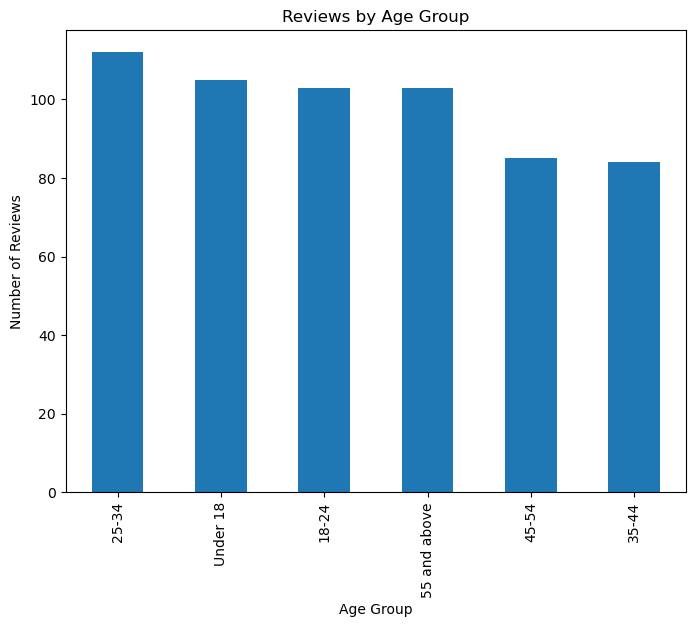

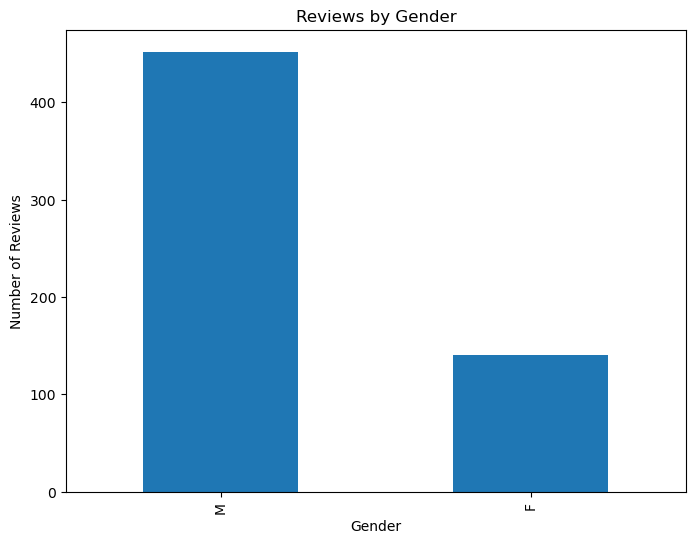

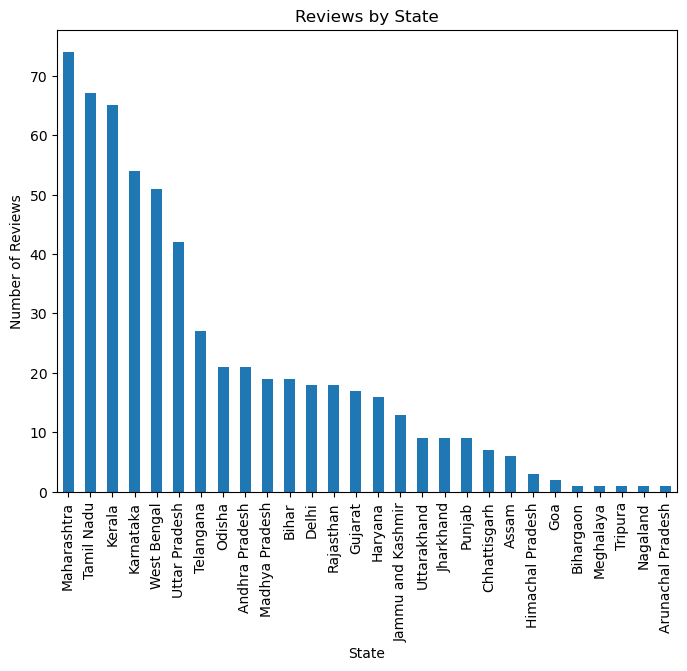

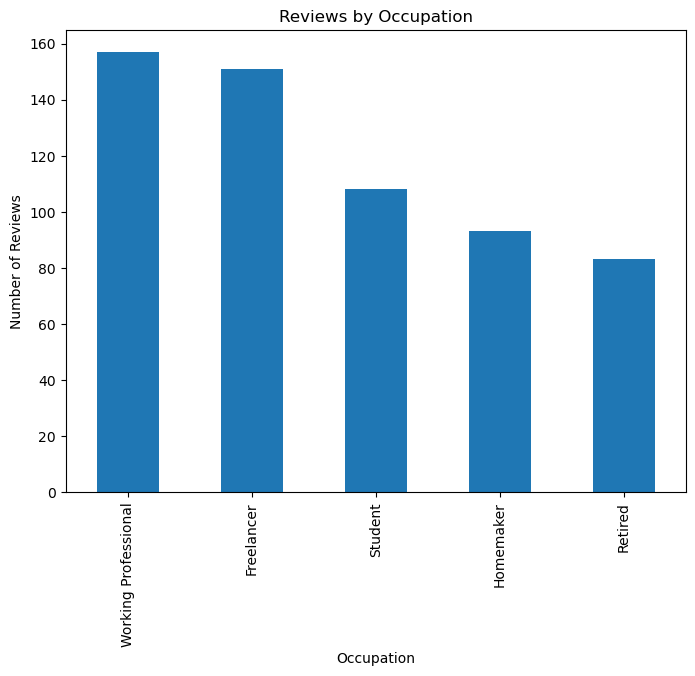

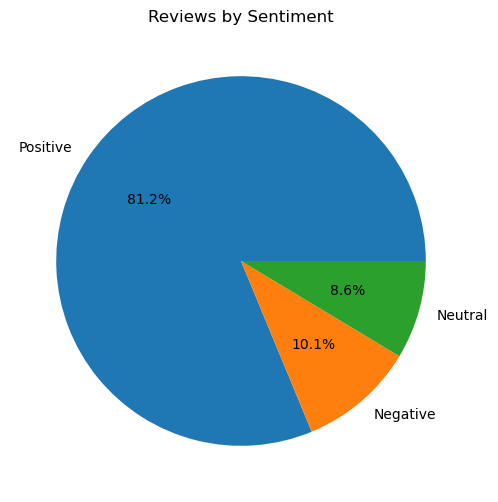

In [59]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender"
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df13)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df13[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df13[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender)

# 3. Reviews by Location
reviews_by_state = df13[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df13[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df13[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_age(Amazfit)[Usage Analysis].png")

plt.show()
plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Amazfit)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Amazfit)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_occupation(Amazfit)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("overall_sentiment(Amazfit)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

In [63]:
df14 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df14.csv")
pd.DataFrame(df14)

,Reviews for Fossil,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I can say it's a well built good looking watch...,25-34,M,"Hyderabad, Telangana",Working Professional,February,2024,Q1
1,Its a good looking watch with all features tha...,55 and above,M,"New Delhi, Delhi",Retired,May,2021,Q2
2,Pretty decent watch! Good for function & party...,35-44,M,"New Delhi, Delhi",Working Professional,October,2021,Q4
3,i m using this product last 4 months. after re...,25-34,M,"Baleshwar, Gujarat",Working Professional,December,2024,Q4
4,Watch is beautiful and elegant. Run hours is a...,Under 18,M,"Gurugram, Haryana",Student,February,2020,Q1
...,...,...,...,...,...,...,...,...
436,After use of more than 1 year watch is OK... l...,Under 18,M,"Amritsar, Punjab",Student,March,2021,Q1
437,Never ever buy any fossil smart product. Waste...,25-34,F,"Gwalior, Madhya Pradesh",Homemaker,June,2021,Q2
438,Loved the watch,55 and above,M,"Thane, Maharashtra",Retired,November,2020,Q4
439,Overall a great buy but battery is so poor nd ...,55 and above,M,"New Delhi, Delhi",Retired,October,2024,Q4


In [65]:
df14.columns = df14.columns.str.strip()
review_column = "Reviews for Fossil"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df14[['Polarity', 'Sentiment']] = df14[review_column].apply(analyze_sentiment)
print(df14.head())

                                  Reviews for Fossil           Age Gender  \
0  I can say it's a well built good looking watch...         25-34      M   
1  Its a good looking watch with all features tha...  55 and above      M   
2  Pretty decent watch! Good for function & party...         35-44      M   
3  i m using this product last 4 months. after re...         25-34      M   
4  Watch is beautiful and elegant. Run hours is a...      Under 18      M   

                Location            Occupation     Month  Year Quarter  \
0   Hyderabad, Telangana  Working Professional  February  2024      Q1   
1       New Delhi, Delhi               Retired       May  2021      Q2   
2       New Delhi, Delhi  Working Professional   October  2021      Q4   
3     Baleshwar, Gujarat  Working Professional  December  2024      Q4   
4      Gurugram, Haryana               Student  February  2020      Q1   

   Polarity Sentiment  
0  0.435417  Positive  
1  0.243750  Positive  
2  0.333333  Positiv

In [66]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df14['state'] = df14['Location'].astype(str).apply(extract_state)
df14

,Reviews for Fossil,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I can say it's a well built good looking watch...,25-34,M,"Hyderabad, Telangana",Working Professional,February,2024,Q1,0.435417,Positive,Telangana
1,Its a good looking watch with all features tha...,55 and above,M,"New Delhi, Delhi",Retired,May,2021,Q2,0.243750,Positive,Delhi
2,Pretty decent watch! Good for function & party...,35-44,M,"New Delhi, Delhi",Working Professional,October,2021,Q4,0.333333,Positive,Delhi
3,i m using this product last 4 months. after re...,25-34,M,"Baleshwar, Gujarat",Working Professional,December,2024,Q4,0.392857,Positive,Gujarat
4,Watch is beautiful and elegant. Run hours is a...,Under 18,M,"Gurugram, Haryana",Student,February,2020,Q1,0.118750,Positive,Haryana
...,...,...,...,...,...,...,...,...,...,...,...
436,After use of more than 1 year watch is OK... l...,Under 18,M,"Amritsar, Punjab",Student,March,2021,Q1,0.500000,Positive,Punjab
437,Never ever buy any fossil smart product. Waste...,25-34,F,"Gwalior, Madhya Pradesh",Homemaker,June,2021,Q2,0.007143,Positive,Madhya Pradesh
438,Loved the watch,55 and above,M,"Thane, Maharashtra",Retired,November,2020,Q4,0.700000,Positive,Maharashtra
439,Overall a great buy but battery is so poor nd ...,55 and above,M,"New Delhi, Delhi",Retired,October,2024,Q4,0.380000,Positive,Delhi


In [69]:
df14 = df14[df14['state'] != 'Maharshtra']

Total Reviews: 440
Reviews by Age Group:
Age
55 and above    80
45-54           78
Under 18        76
18-24           72
25-34           71
35-44           63
Name: count, dtype: int64
Reviews by Gender:
Gender
M    327
F    113
Name: count, dtype: int64
Reviews by State:
state
Maharashtra          76
Telangana            46
Karnataka            46
Tamil Nadu           30
Andhra Pradesh       30
Gujarat              27
Delhi                22
Uttar Pradesh        21
Kerala               21
West Bengal          21
Odisha               19
Punjab               14
Haryana              13
Madhya Pradesh       11
Rajasthan             9
Chhattisgarh          6
Bihar                 5
Uttarakhand           5
Jharkhand             4
Goa                   4
Assam                 4
Tripura               2
Himachal Pradesh      2
Jammu and Kashmir     2
Name: count, dtype: int64
Reviews by Occupation:
Occupation
Working Professional    122
Freelancer              108
Student                  77
H

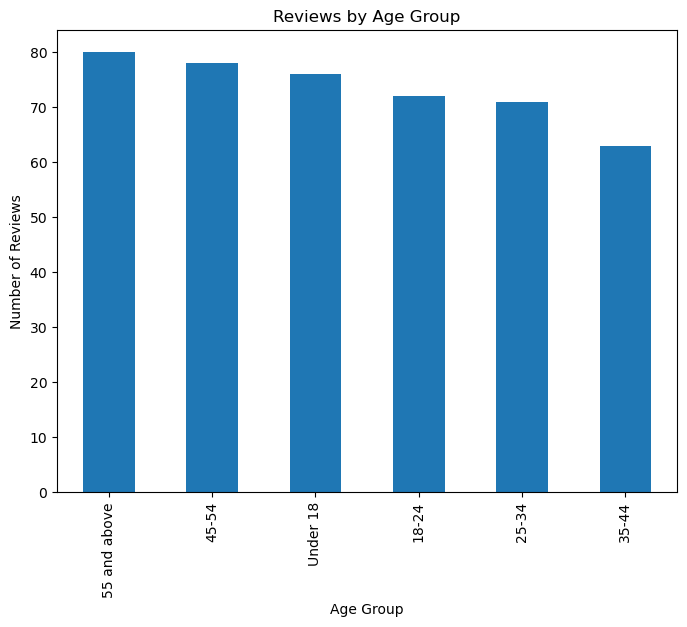

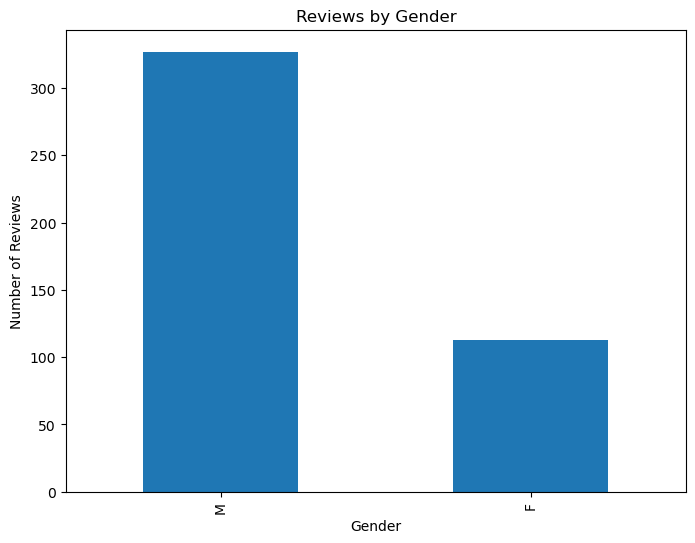

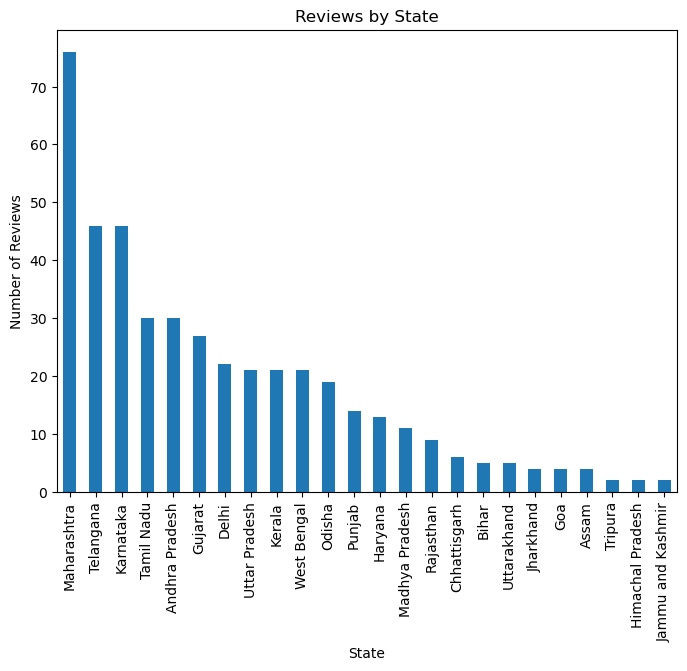

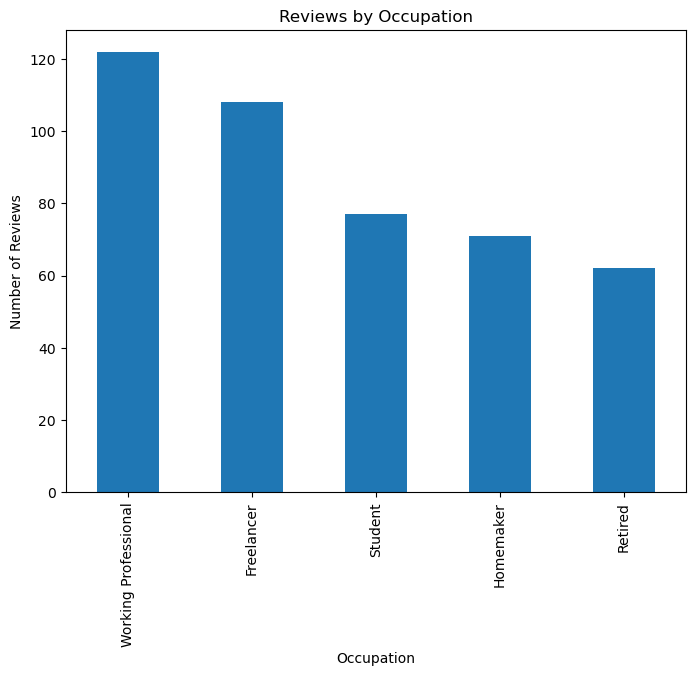

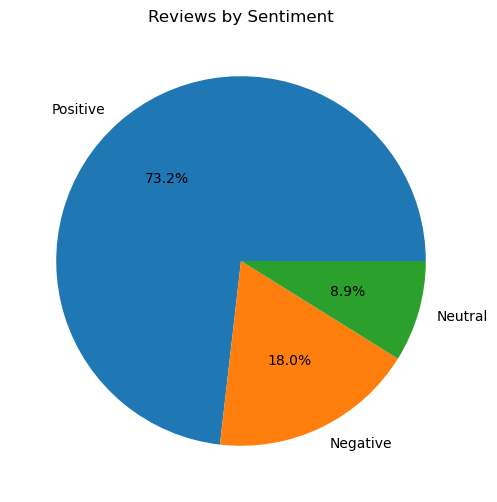

In [71]:
import matplotlib.pyplot as plt
# Replace these with actual column names in your dataset
sentiment_column = "Sentiment"
age_column = "Age"
gender_column = "Gender" 
state_column = "state"
occupation_column = "Occupation"

# 1. Total reviews count
total_reviews = len(df14)
print(f"Total Reviews: {total_reviews}")

# 2. Reviews by Age Group
reviews_by_age_group = df14[age_column].value_counts()
print("Reviews by Age Group:")
print(reviews_by_age_group)
reviews_by_gender = df14[gender_column].value_counts()
print("Reviews by Gender:")
print(reviews_by_gender)

# 3. Reviews by Location
reviews_by_state = df14[state_column].value_counts()
print("Reviews by State:")
print(reviews_by_state)

# 4. Reviews by Occupation
reviews_by_occupation = df14[occupation_column].value_counts()
print("Reviews by Occupation:")
print(reviews_by_occupation)

# 5. Reviews by Sentiment
reviews_by_sentiment = df14[sentiment_column].value_counts()
print("Reviews by Sentiment:")
print(reviews_by_sentiment)

# Visualization: Reviews by Age Group
plt.figure(figsize=(8, 6))
reviews_by_age_group.plot(kind='bar', title="Reviews by Age Group", ylabel="Number of Reviews", xlabel="Age Group")
plt.savefig("sentiment_by_age(Fossil)[Usage Analysis].png")

plt.show()
plt.figure(figsize=(8, 6))
reviews_by_gender.plot(kind='bar', title="Reviews by Gender", ylabel="Number of Reviews", xlabel="Gender")
plt.savefig("sentiment_by_gender(Fossil)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Location
plt.figure(figsize=(8, 6))
reviews_by_state.plot(kind='bar', title="Reviews by State", ylabel="Number of Reviews", xlabel="State")
plt.savefig("sentiment_by_state(Fossil)[Usage Analysis].png")

plt.show()

plt.figure(figsize=(8, 6))
reviews_by_occupation.plot(kind='bar', title="Reviews by Occupation", ylabel="Number of Reviews", xlabel="Occupation")
plt.savefig("sentiment_by_occupation(Fossil)[Usage Analysis].png")

plt.show()

# Visualization: Reviews by Sentiment
plt.figure(figsize=(8, 6))
reviews_by_sentiment.plot(kind='pie', autopct='%1.1f%%', title="Reviews by Sentiment")
plt.savefig("overall_sentiment(Fossil)[Usage Analysis].png")

plt.ylabel('')  # Remove y-axis label for a cleaner pie chart
plt.show()

## Market Trend Analysis

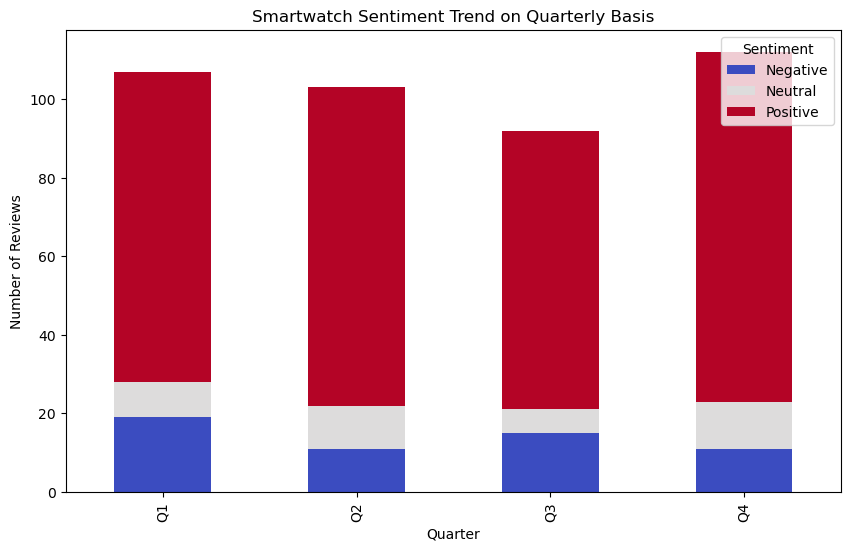

In [91]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df1.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Samsung)[Market Trend Analysis].png")
plt.show()


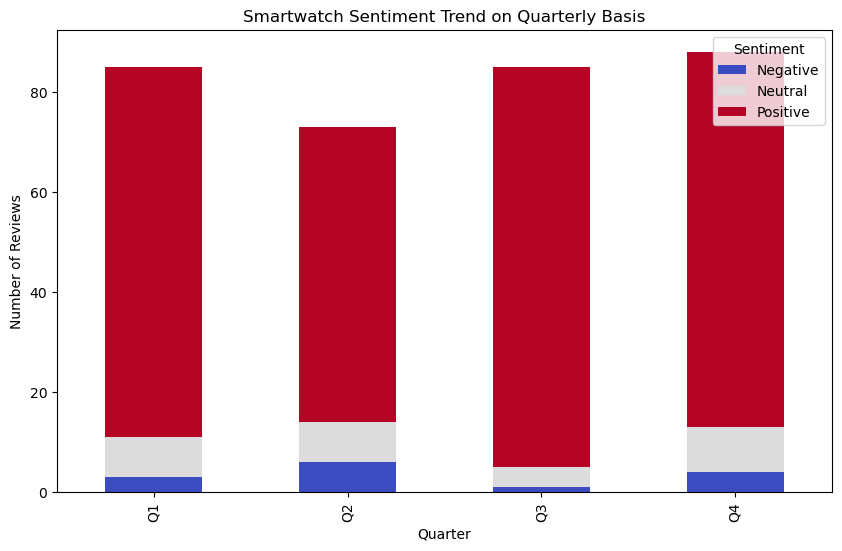

In [103]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment1 = df2.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment1.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Apple)[Usage Analysis].png")
plt.show()


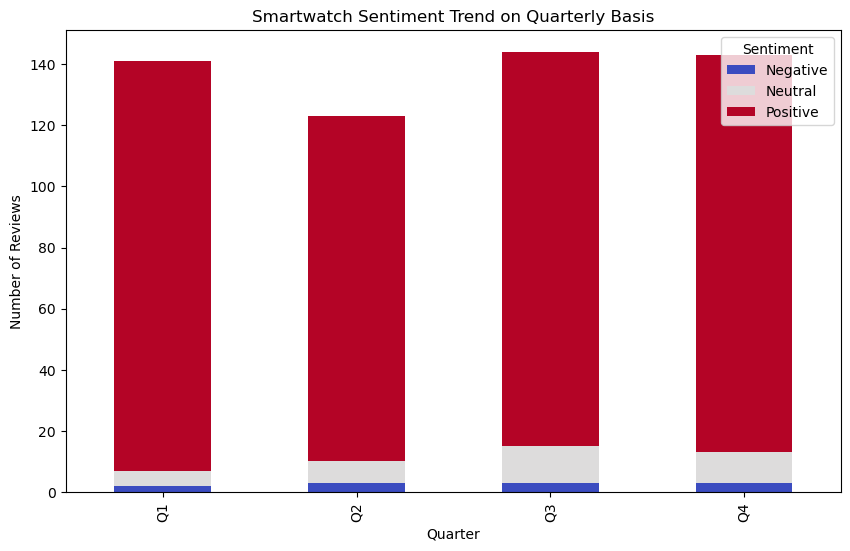

In [494]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df3.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.savefig("sentiment_by_gender(Noise)[Usage Analysis].png")

plt.legend(title="Sentiment")
plt.show()


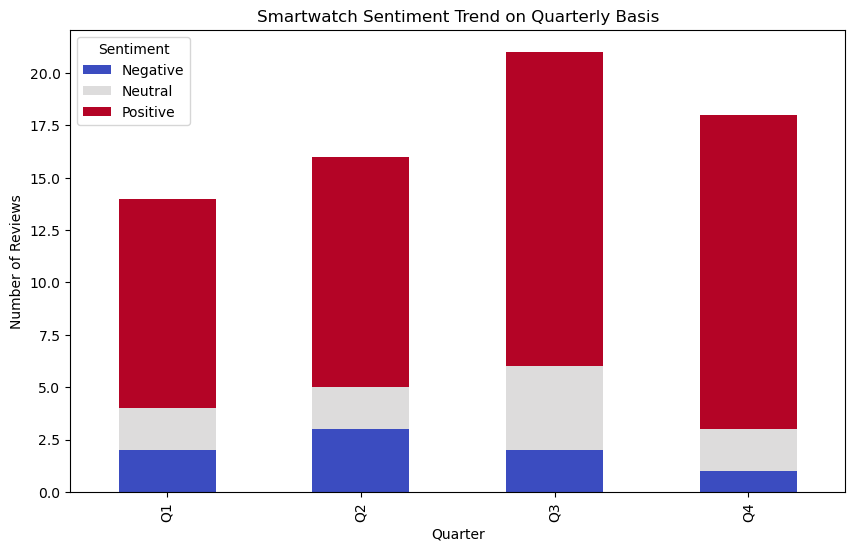

In [496]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df4.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise()[Usage Analysis].png")

plt.show()


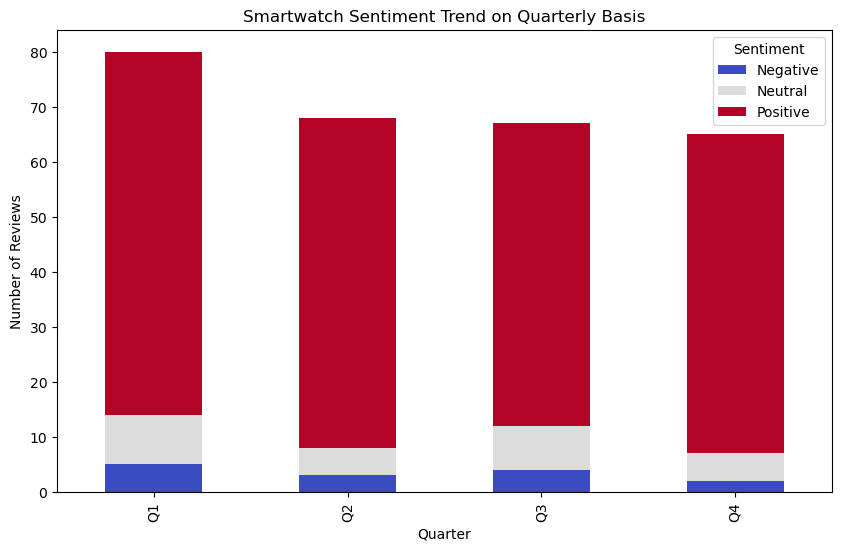

In [123]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df5.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.savefig("sentiment_trend_quarterwise(Redmi)[Market Trend Analysis].png")

plt.legend(title="Sentiment")
plt.show()


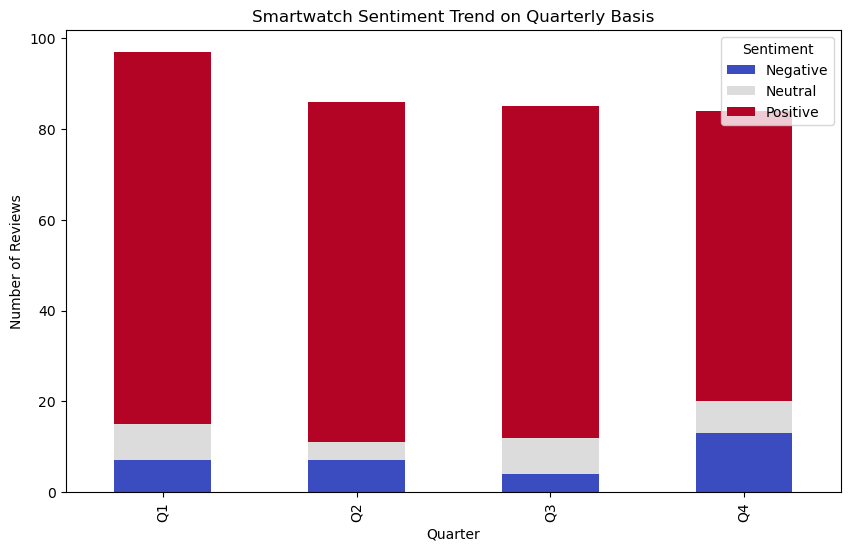

In [500]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df6.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.show()


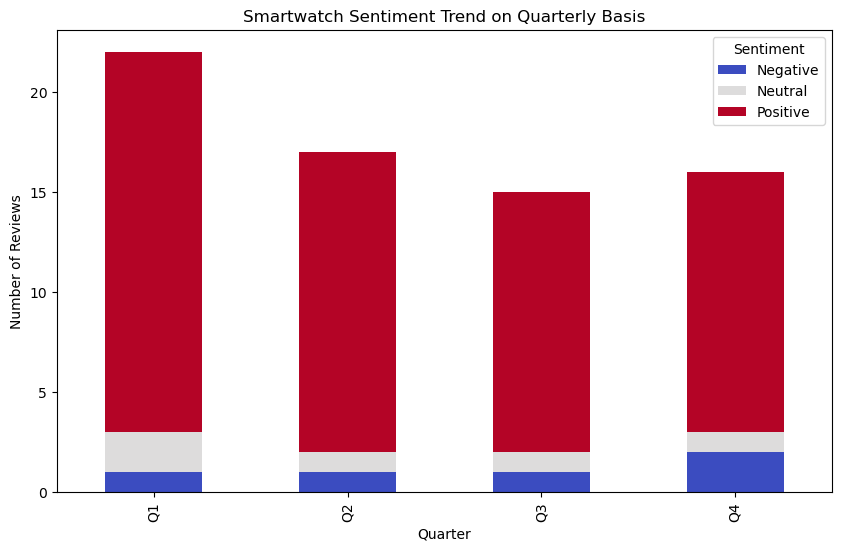

In [131]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df7.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Google)[Usage Analysis].png")

plt.show()


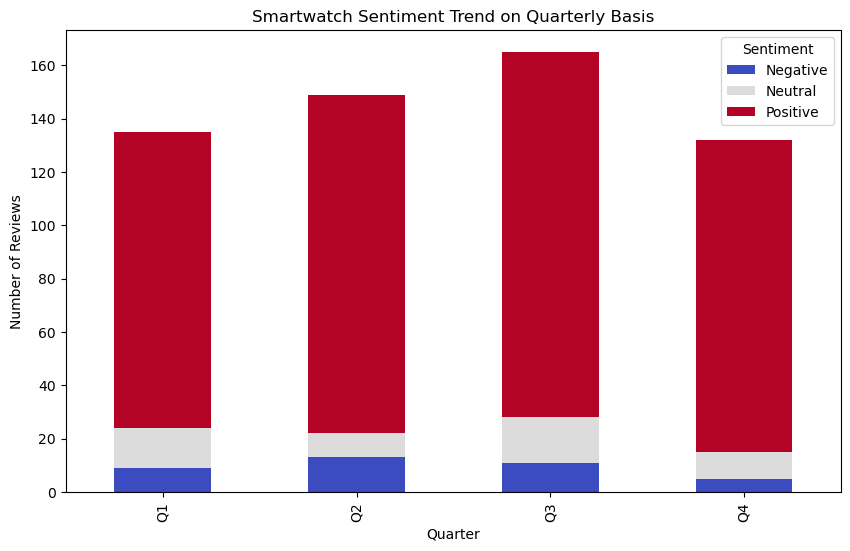

In [139]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df8.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Boat)[Market Trend Analysis].png")

plt.show()


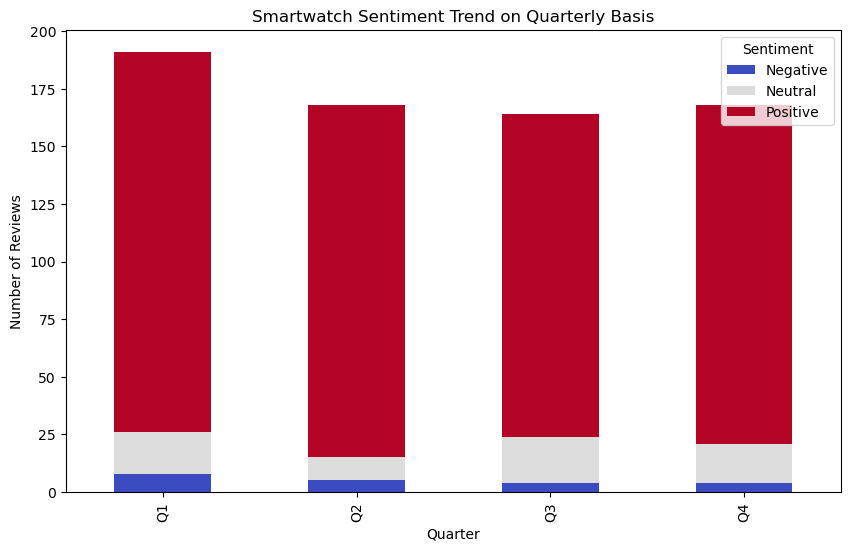

In [506]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df9.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.show()


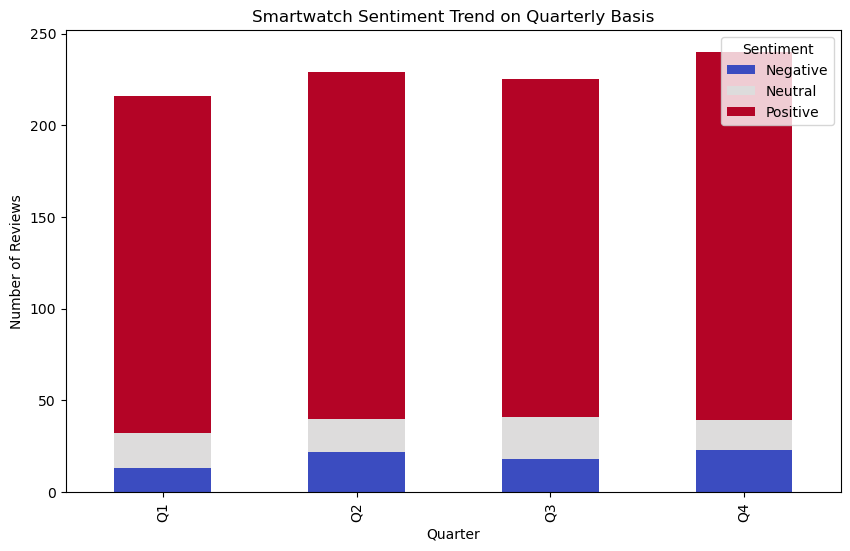

In [141]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df10.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Fireboltt)[Market Trend Analysis].png")

plt.show()


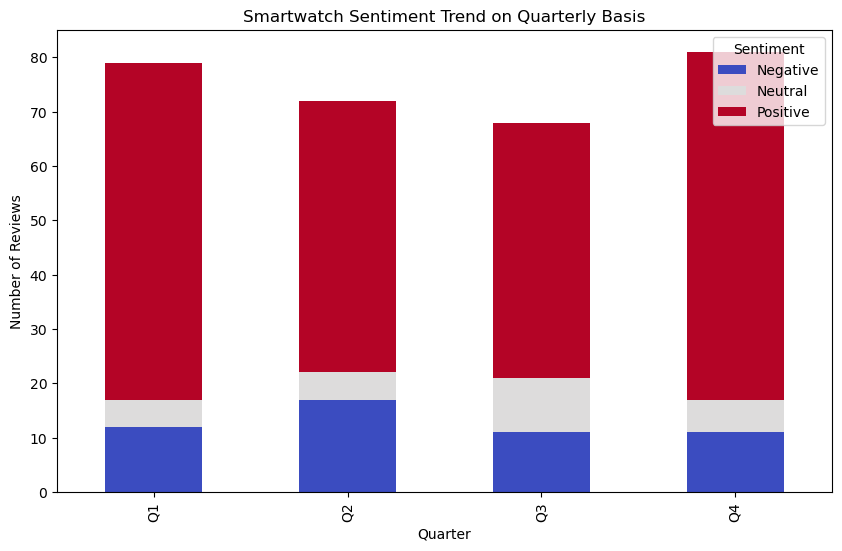

In [143]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df11.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(FitBit)[Market Trend Analysis].png")

plt.show()


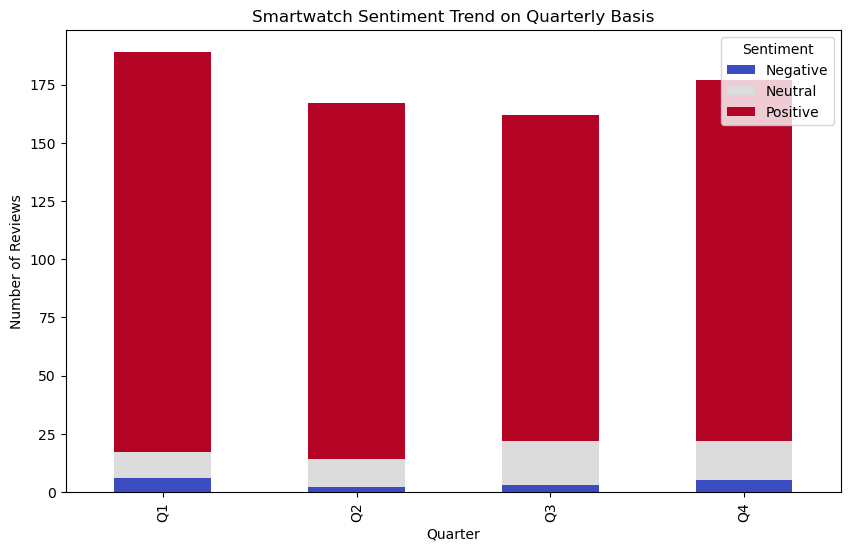

In [145]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df12.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Boult)[Market Trend Analysis].png")

plt.show()


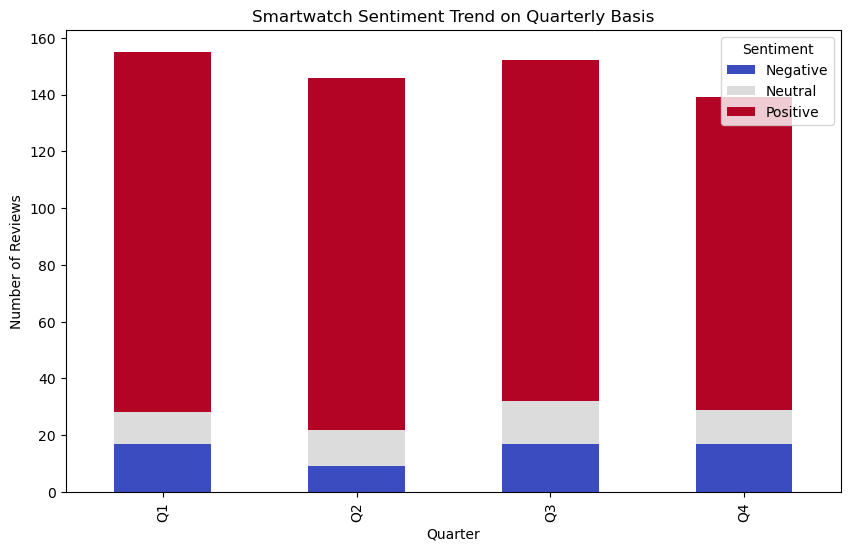

In [147]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df13.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Amazfit)[Market Trend Analysis].png")

plt.show()


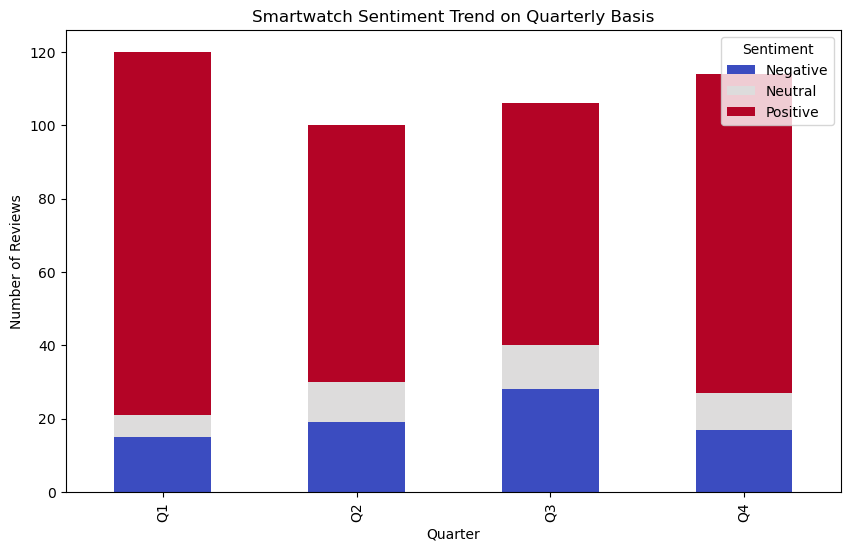

In [149]:
import seaborn as sns

# Group by Season & Sentiment
seasonal_sentiment = df14.groupby(["Quarter", "Sentiment"]).size().unstack().fillna(0)

# Plot
seasonal_sentiment.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Quarter")
plt.ylabel("Number of Reviews")
plt.title("Smartwatch Sentiment Trend on Quarterly Basis")
plt.legend(title="Sentiment")
plt.savefig("sentiment_trend_quarterwise(Fossil)[Market Trend Analysis].png")

plt.show()
